In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [11]:
df[df.duplicated(keep=False)]['Class'].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [12]:
# STEP 1: Create a separate dataframe containing all duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]

# STEP 2: Check how many rows are involved in duplicates
print("Duplicate rows involved:", duplicate_rows.shape[0])

# STEP 3: Check how many duplicate groups have 2, 3, 4, etc. occurrences
duplicate_group_sizes = duplicate_rows.groupby(list(df.columns)).size()
print("\nDuplicate group sizes:")
print(duplicate_group_sizes.value_counts().sort_index())

# STEP 4: Check duplicated rows by fraud status
print("\nClass distribution among duplicate rows:")
print(duplicate_rows['Class'].value_counts())

# STEP 5: Check the number of unique values in the target column
print("\nUnique Class values:")
print(df['Class'].unique())

# STEP 6: Generate a statistical summary of the dataset
print("\nStatistical Summary:")
display(df.describe())

Duplicate rows involved: 1854

Duplicate group sizes:
2     611
3      66
4      81
5      10
6       1
9       2
18      2
Name: count, dtype: int64

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64

Unique Class values:
[0 1]

Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


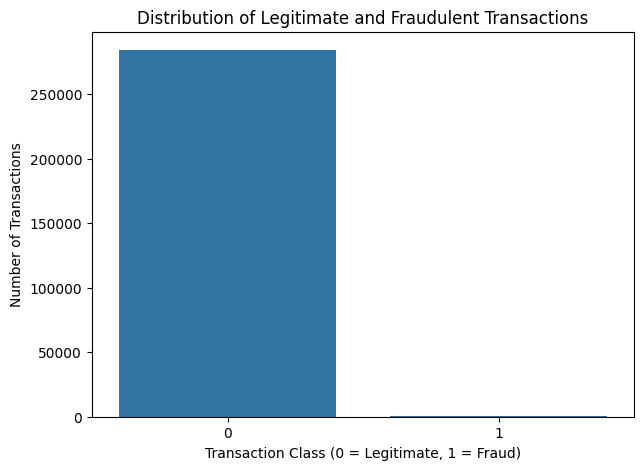

Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


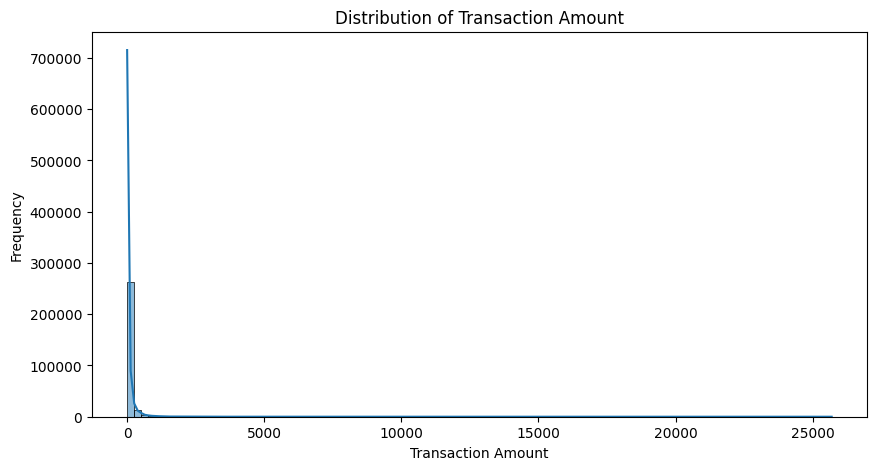

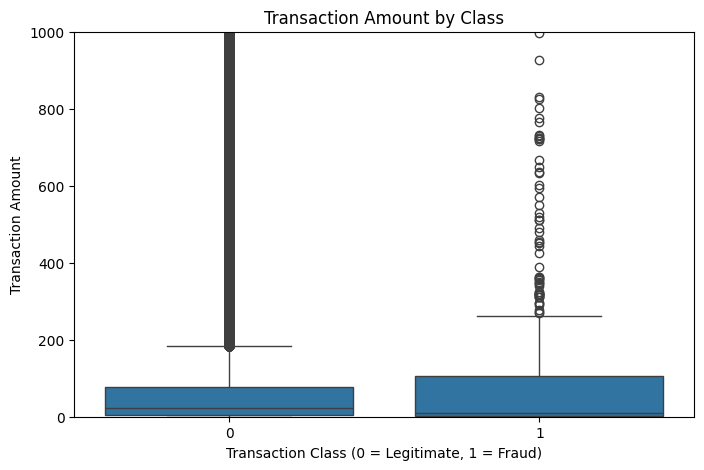

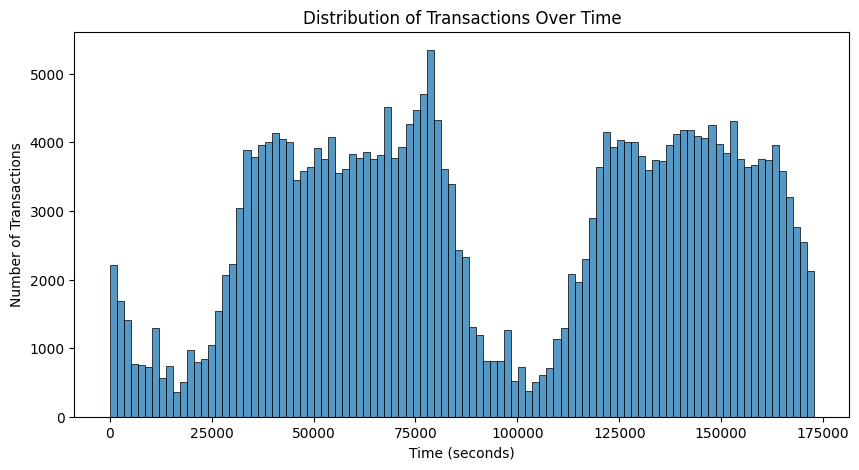

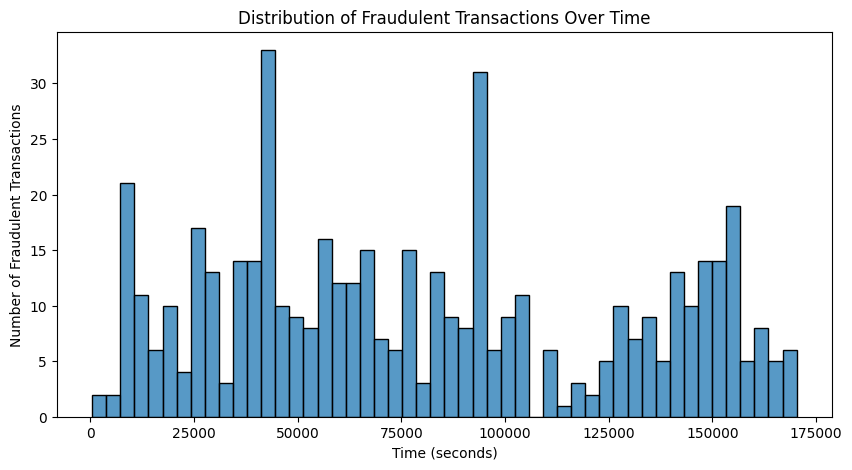

In [13]:
# ==========================================
# STEP 1: Class distribution
# ==========================================

class_counts = df['Class'].value_counts()

plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Legitimate and Fraudulent Transactions')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()


# ==========================================
# STEP 2: Class distribution as percentages
# ==========================================

class_percent = df['Class'].value_counts(normalize=True) * 100

print("Class Distribution (%):")
print(class_percent)


# ==========================================
# STEP 3: Transaction Amount distribution
# ==========================================

plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=100, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


# ==========================================
# STEP 4: Transaction Amount by Class
# ==========================================

plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.ylim(0, 1000)
plt.show()


# ==========================================
# STEP 5: Transaction Time distribution
# ==========================================

plt.figure(figsize=(10, 5))
sns.histplot(df['Time'], bins=100)
plt.title('Distribution of Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Transactions')
plt.show()


# ==========================================
# STEP 6: Fraud transactions over Time
# ==========================================

fraud_df = df[df['Class'] == 1]

plt.figure(figsize=(10, 5))
sns.histplot(fraud_df['Time'], bins=50)
plt.title('Distribution of Fraudulent Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

Time range in hours:
Minimum: 0.00 hours
Maximum: 48.00 hours

Transactions by day:
Day
0    144786
1    140021
Name: count, dtype: int64

Transactions by hour:
Hour
0      7695
1      4220
2      3328
3      3492
4      2209
5      2990
6      4101
7      7243
8     10276
9     15838
10    16598
11    16856
12    15420
13    15365
14    16570
15    16461
16    16453
17    16166
18    17039
19    15649
20    16756
21    17703
22    15441
23    10938
Name: count, dtype: int64

Fraud rate by hour:


,Transactions,Fraud,Fraud_Rate_%
Hour,,,
0,7695,6,0.077973
1,4220,10,0.236967
2,3328,57,1.712740
3,3492,17,0.486827
4,2209,23,1.041195
5,2990,11,0.367893
6,4101,9,0.219459
7,7243,23,0.317548
8,10276,9,0.087583


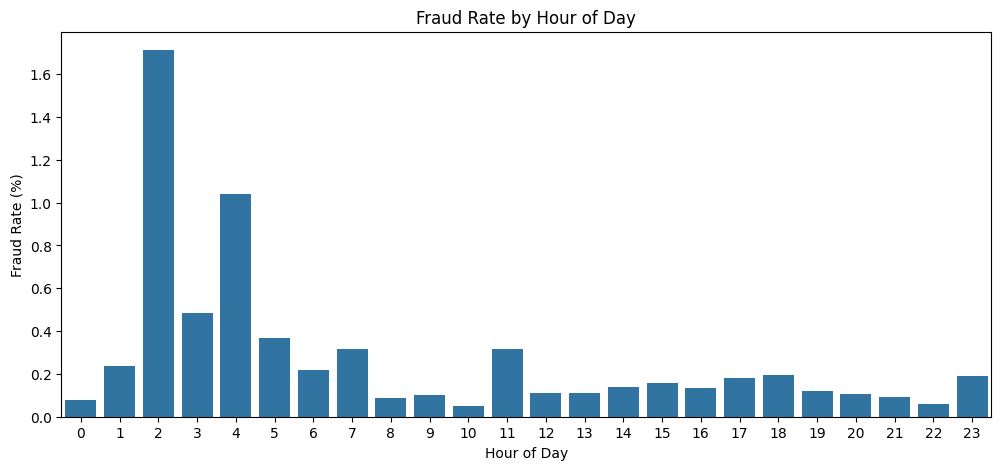


Transaction Amount Statistics by Class:


,count,mean,median,max
Class,,,,
0,284315,88.291022,22.00,25691.16
1,492,122.211321,9.25,2125.87


In [14]:
# ==========================================
# STEP 1: Convert elapsed seconds to hours
# ==========================================

df['Time_Hours'] = df['Time'] / 3600

print("Time range in hours:")
print(f"Minimum: {df['Time_Hours'].min():.2f} hours")
print(f"Maximum: {df['Time_Hours'].max():.2f} hours")


# ==========================================
# STEP 2: Create approximate day information
# ==========================================

df['Day'] = (df['Time'] // 86400).astype(int)

print("\nTransactions by day:")
print(df['Day'].value_counts().sort_index())


# ==========================================
# STEP 3: Create hour-of-day feature
# ==========================================

df['Hour'] = ((df['Time'] % 86400) // 3600).astype(int)

print("\nTransactions by hour:")
print(df['Hour'].value_counts().sort_index())


# ==========================================
# STEP 4: Compare fraud rate by hour
# ==========================================

fraud_by_hour = df.groupby('Hour')['Class'].agg(
    Transactions='count',
    Fraud='sum'
)

fraud_by_hour['Fraud_Rate_%'] = (
    fraud_by_hour['Fraud'] /
    fraud_by_hour['Transactions'] * 100
)

print("\nFraud rate by hour:")
display(fraud_by_hour)


# ==========================================
# STEP 5: Visualize fraud rate by hour
# ==========================================

plt.figure(figsize=(12, 5))

sns.barplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour['Fraud_Rate_%']
)

plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.show()


# ==========================================
# STEP 6: Compare average transaction amount
# ==========================================

amount_by_class = df.groupby('Class')['Amount'].agg(
    ['count', 'mean', 'median', 'max']
)

print("\nTransaction Amount Statistics by Class:")
display(amount_by_class)

Features negatively correlated with fraud:


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64


Features positively correlated with fraud:


V28      0.009536
V27      0.017580
V8       0.019875
V20      0.020090
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64

Top 10 features by absolute correlation with Class:


V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

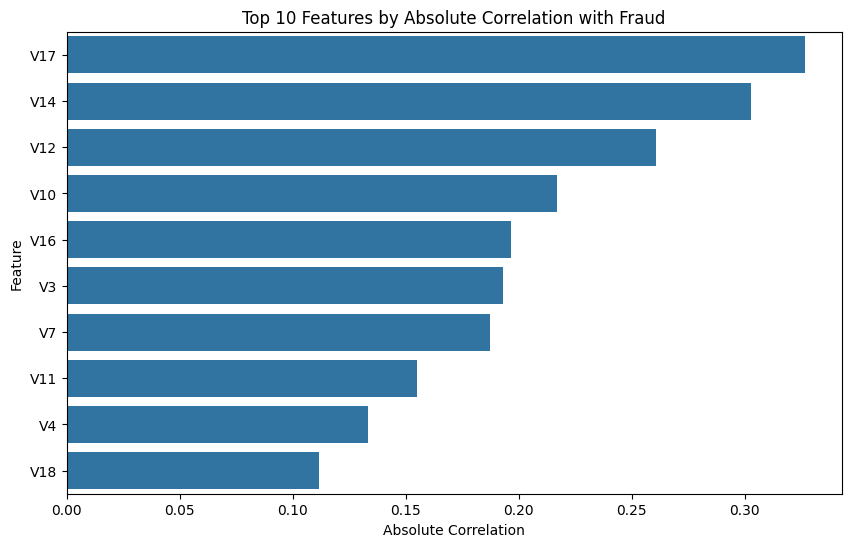

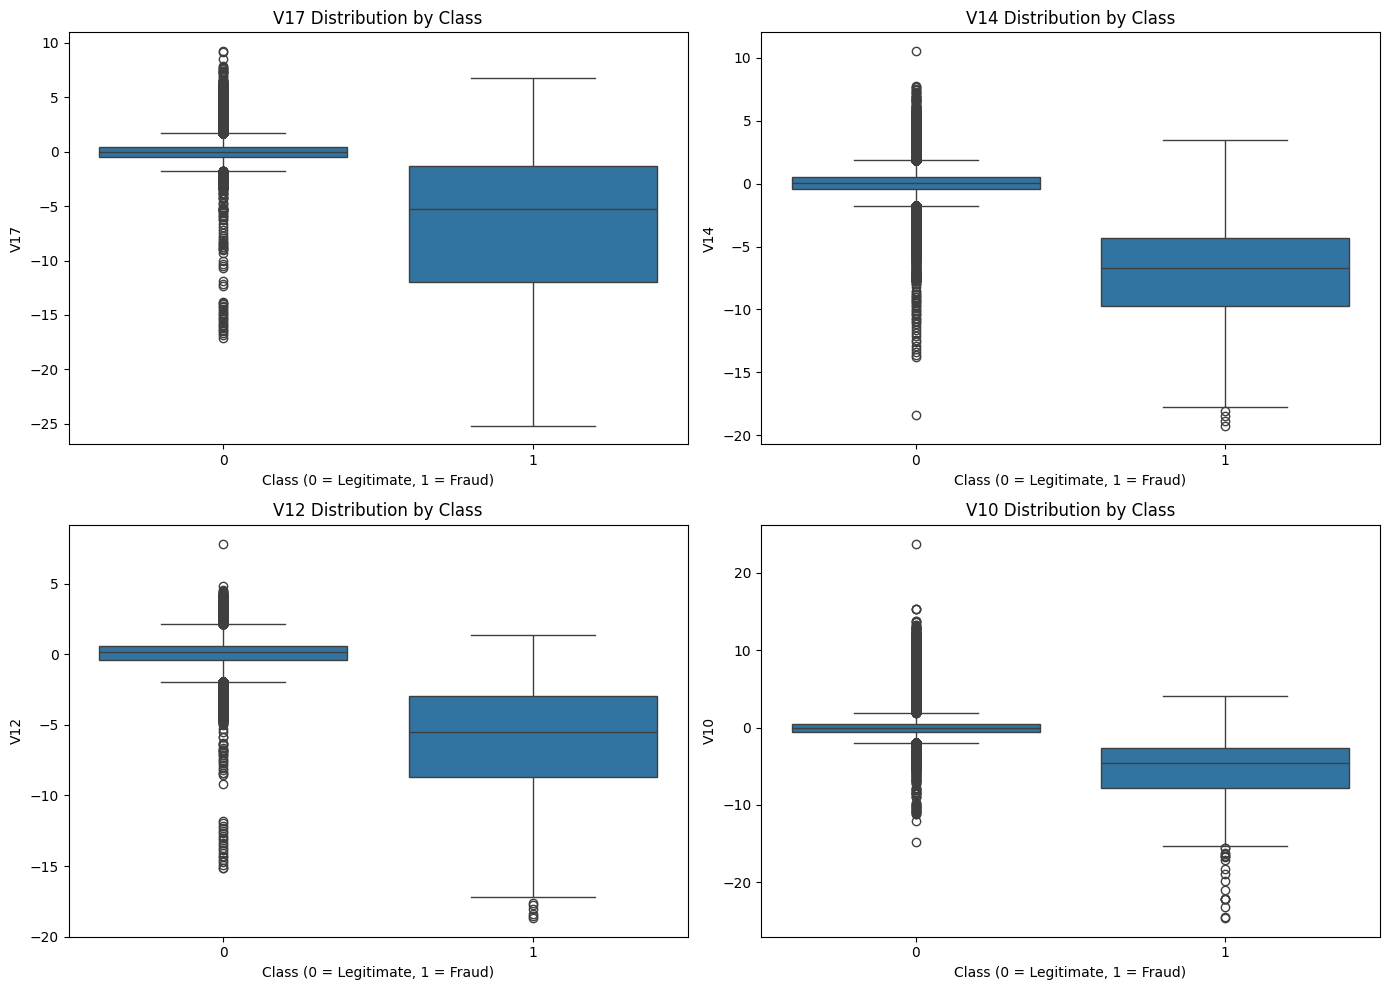

Mean values of top features by class:


Class,0,1
V17,0.011535,-6.665836
V14,0.012064,-6.971723
V12,0.010832,-6.259393
V10,0.009824,-5.676883
V16,0.007164,-4.139946
V3,0.012171,-7.033281
V7,0.009637,-5.568731
V11,-0.006576,3.800173
V4,-0.007860,4.542029
V18,0.003887,-2.246308


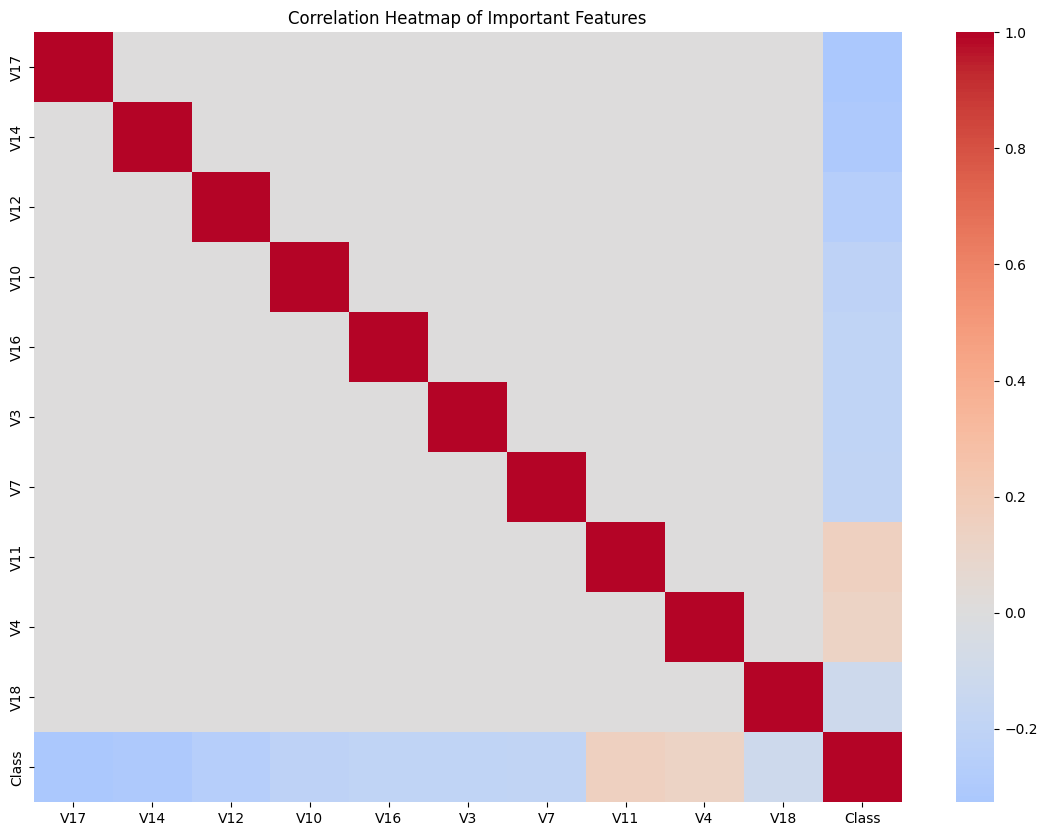

In [15]:
# ==========================================
# STEP 1: Correlation with fraud target
# ==========================================

correlations = df.corr(numeric_only=True)['Class'].sort_values()

print("Features negatively correlated with fraud:")
display(correlations.head(10))

print("\nFeatures positively correlated with fraud:")
display(correlations.tail(10))


# ==========================================
# STEP 2: Top features by absolute correlation
# ==========================================

abs_correlations = correlations.drop('Class').abs().sort_values(ascending=False)

print("Top 10 features by absolute correlation with Class:")
display(abs_correlations.head(10))


# ==========================================
# STEP 3: Plot top correlated features
# ==========================================

top_features = abs_correlations.head(10).index

plt.figure(figsize=(10, 6))

sns.barplot(
    x=abs_correlations[top_features].values,
    y=top_features
)

plt.title('Top 10 Features by Absolute Correlation with Fraud')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.show()


# ==========================================
# STEP 4: Compare top features by class
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), top_features[:4]):
    sns.boxplot(
        x='Class',
        y=feature,
        data=df,
        ax=ax
    )
    ax.set_title(f'{feature} Distribution by Class')
    ax.set_xlabel('Class (0 = Legitimate, 1 = Fraud)')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


# ==========================================
# STEP 5: Calculate mean values by class
# ==========================================

feature_means = df.groupby('Class')[list(top_features)].mean().T

print("Mean values of top features by class:")
display(feature_means)


# ==========================================
# STEP 6: Check correlations between features
# ==========================================

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[list(top_features) + ['Class']].corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Important Features')
plt.show()

Number of V features: 28
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

V-features with largest difference in mean:


Class,0,1,Absolute_Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749



V-features with largest difference in median:


Class,0,1,Absolute_Difference
V14,0.051947,-6.729720,6.781667
V12,0.141679,-5.502530,5.644208
V3,0.182158,-5.075257,5.257415
V17,-0.064833,-5.302949,5.238115
V10,-0.091872,-4.578825,4.486953
V4,-0.022405,4.177147,4.199552
V11,-0.034923,3.586218,3.621142
V16,0.067377,-3.549795,3.617172
V7,0.041138,-3.034402,3.075540
V2,0.064070,2.717869,2.653799


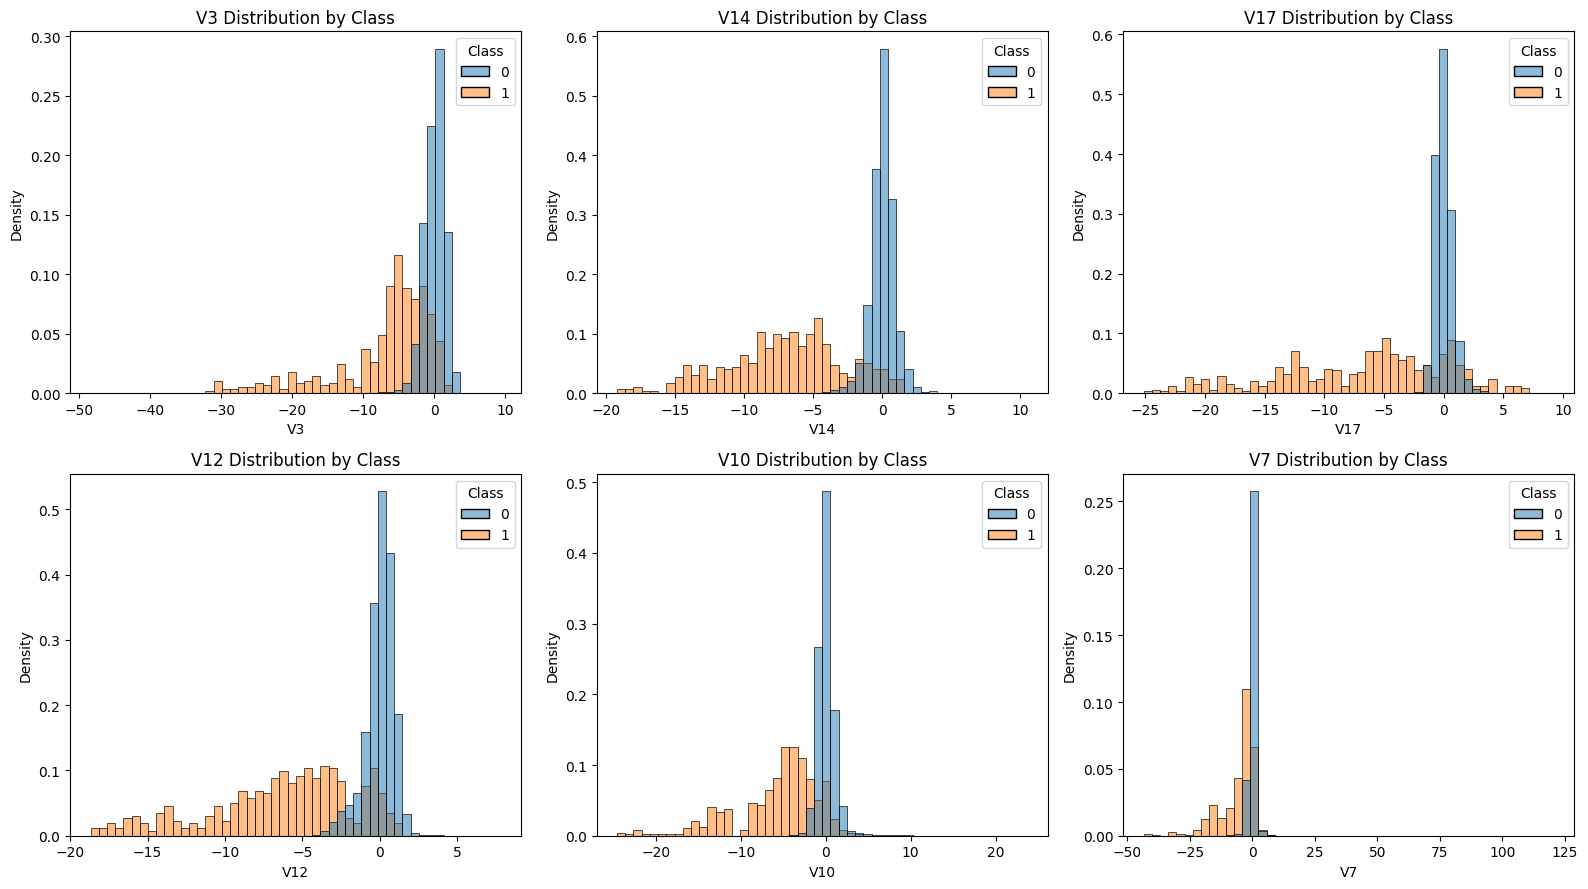


Amount skewness:
16.977724453761006

Most skewed V-features:


V28    11.192091
V8     -8.521944
V23    -5.875140
V2     -4.624866
V17    -3.844914
V21     3.592991
V1     -3.280667
V7      2.553907
V5     -2.425901
V12    -2.278401
dtype: float64

In [16]:
# ==========================================
# STEP 1: Define V features
# ==========================================

v_features = [f'V{i}' for i in range(1, 29)]

print("Number of V features:", len(v_features))
print(v_features)


# ==========================================
# STEP 2: Calculate mean difference
# ==========================================

mean_comparison = df.groupby('Class')[v_features].mean().T

mean_comparison['Absolute_Difference'] = (
    mean_comparison[1] - mean_comparison[0]
).abs()

mean_comparison = mean_comparison.sort_values(
    'Absolute_Difference',
    ascending=False
)

print("\nV-features with largest difference in mean:")
display(mean_comparison.head(15))


# ==========================================
# STEP 3: Calculate median difference
# ==========================================

median_comparison = df.groupby('Class')[v_features].median().T

median_comparison['Absolute_Difference'] = (
    median_comparison[1] - median_comparison[0]
).abs()

median_comparison = median_comparison.sort_values(
    'Absolute_Difference',
    ascending=False
)

print("\nV-features with largest difference in median:")
display(median_comparison.head(15))


# ==========================================
# STEP 4: Plot distributions of top 6 features
# ==========================================

top_6_features = mean_comparison.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flatten(), top_6_features):
    sns.histplot(
        data=df,
        x=feature,
        hue='Class',
        bins=50,
        stat='density',
        common_norm=False,
        ax=ax
    )
    ax.set_title(f'{feature} Distribution by Class')

plt.tight_layout()
plt.show()


# ==========================================
# STEP 5: Check skewness of Amount
# ==========================================

print("\nAmount skewness:")
print(df['Amount'].skew())


# ==========================================
# STEP 6: Check skewness of V-features
# ==========================================

v_skewness = df[v_features].skew().sort_values(
    key=abs,
    ascending=False
)

print("\nMost skewed V-features:")
display(v_skewness.head(10))

Transaction Amount Statistics:


,Count,Mean,Median,Std,Min,Max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


Zero-amount transactions: 1825

Zero-amount transactions by class:
Class
0    1798
1      27
Name: count, dtype: int64
Top 10 highest-value transactions:


,Time,Amount,Class
274771,166198.0,25691.16,0
58465,48401.0,19656.53,0
151296,95286.0,18910.00,0
46841,42951.0,12910.93,0
54018,46253.0,11898.09,0
169457,119713.0,11789.84,0
284249,172273.0,10199.44,0
227921,145283.0,10000.00,0
74699,55709.0,8790.26,0
245474,152763.0,8787.00,0


Top 10 highest-value fraudulent transactions:


,Time,Amount,Class
176049,122608.0,2125.87,1
6971,9064.0,1809.68,1
249167,154278.0,1504.93,1
89190,62467.0,1402.16,1
81609,59011.0,1389.56,1
95597,65385.0,1354.25,1
199896,133184.0,1335.00,1
10690,18088.0,1218.89,1
249239,154309.0,1096.99,1
233258,147501.0,996.27,1


Fraud rate by transaction amount decile:


,Transactions,Fraud,Fraud_Rate_%
Amount_Bin,,,
"(-0.001, 1.0]",30492,181,0.593598
"(1.0, 3.57]",26473,27,0.101991
"(3.57, 8.91]",28559,36,0.126055
"(8.91, 13.0]",28405,13,0.045767
"(13.0, 22.0]",28714,14,0.048757
"(22.0, 37.0]",28375,17,0.059912
"(37.0, 59.8]",28366,24,0.084608
"(59.8, 100.0]",28915,50,0.172921
"(100.0, 203.0]",28050,45,0.160428


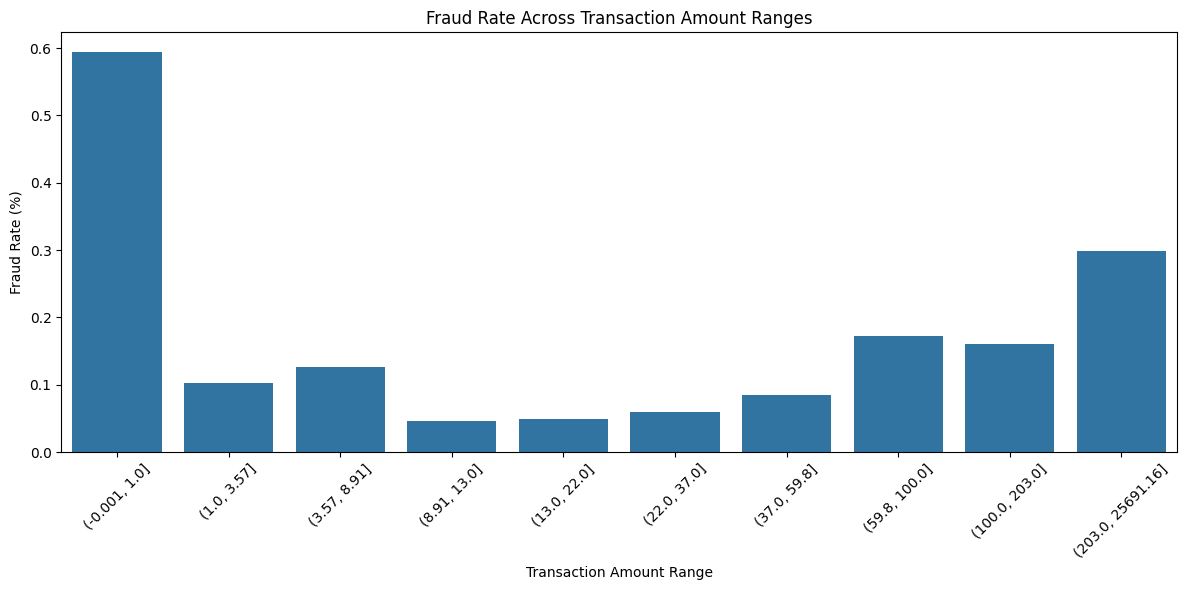

In [17]:
# ==========================================
# STEP 1: Compare Amount statistics
# ==========================================

amount_stats = df.groupby('Class')['Amount'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
)

print("Transaction Amount Statistics:")
display(amount_stats)


# ==========================================
# STEP 2: Check zero-value transactions
# ==========================================

zero_amount = df[df['Amount'] == 0]

print("Zero-amount transactions:", len(zero_amount))
print("\nZero-amount transactions by class:")
print(zero_amount['Class'].value_counts())


# ==========================================
# STEP 3: Find the largest transactions
# ==========================================

print("Top 10 highest-value transactions:")
display(
    df.nlargest(10, 'Amount')[['Time', 'Amount', 'Class']]
)


# ==========================================
# STEP 4: Find the largest fraudulent transactions
# ==========================================

print("Top 10 highest-value fraudulent transactions:")
display(
    df[df['Class'] == 1]
    .nlargest(10, 'Amount')[['Time', 'Amount', 'Class']]
)


# ==========================================
# STEP 5: Compare fraud rate across amount ranges
# ==========================================

df['Amount_Bin'] = pd.qcut(
    df['Amount'],
    q=10,
    duplicates='drop'
)

amount_fraud_rate = df.groupby(
    'Amount_Bin',
    observed=True
)['Class'].agg(
    Transactions='count',
    Fraud='sum'
)

amount_fraud_rate['Fraud_Rate_%'] = (
    amount_fraud_rate['Fraud'] /
    amount_fraud_rate['Transactions'] * 100
)

print("Fraud rate by transaction amount decile:")
display(amount_fraud_rate)


# ==========================================
# STEP 6: Visualize fraud rate by amount range
# ==========================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=amount_fraud_rate.index.astype(str),
    y=amount_fraud_rate['Fraud_Rate_%']
)

plt.title('Fraud Rate Across Transaction Amount Ranges')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# STEP 1: Check duplicate groups by class
# ==========================================

duplicate_groups = (
    df[df.duplicated(keep=False)]
    .groupby(list(df.columns.drop(['Time_Hours', 'Day', 'Hour', 'Amount_Bin'])))
    .size()
)

print("Number of duplicate groups:", len(duplicate_groups))
print("\nDuplicate group size distribution:")
print(duplicate_groups.value_counts().sort_index())


# ==========================================
# STEP 2: Check whether Time is unique
# ==========================================

print("Number of unique Time values:", df['Time'].nunique())
print("Total transactions:", len(df))

print("\nMost common Time values:")
display(df['Time'].value_counts().head(10))


# ==========================================
# STEP 3: Compare V-feature standard deviations
# ==========================================

v_features = [f'V{i}' for i in range(1, 29)]

v_std = df[v_features].std().sort_values(ascending=False)

print("V-feature standard deviations:")
display(v_std)


# ==========================================
# STEP 4: Find features with strongest
# correlation with each other
# ==========================================

feature_corr = df[v_features].corr().abs()

# Remove self-correlations
np.fill_diagonal(feature_corr.values, 0)

strong_pairs = (
    feature_corr.stack()
    .sort_values(ascending=False)
)

print("Top 15 strongest correlations between V-features:")
display(strong_pairs.head(15))


# ==========================================
# STEP 5: Check for infinite values
# ==========================================

print("Total infinite values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


# ==========================================
# STEP 6: Check data types and memory
# ==========================================

print("\nData types:")
display(df.dtypes.value_counts())

print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Number of duplicate groups: 773

Duplicate group size distribution:
2     611
3      66
4      81
5      10
6       1
9       2
18      2
Name: count, dtype: int64
Number of unique Time values: 124592
Total transactions: 284807

Most common Time values:


Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
128860.0    19
19912.0     19
140347.0    19
3750.0      19
143083.0    18
Name: count, dtype: int64

V-feature standard deviations:


V1     1.958696
V2     1.651309
V3     1.516255
V4     1.415869
V5     1.380247
V6     1.332271
V7     1.237094
V8     1.194353
V9     1.098632
V10    1.088850
V11    1.020713
V12    0.999201
V13    0.995274
V14    0.958596
V15    0.915316
V16    0.876253
V17    0.849337
V18    0.838176
V19    0.814041
V20    0.770925
V21    0.734524
V22    0.725702
V23    0.624460
V24    0.605647
V25    0.521278
V26    0.482227
V27    0.403632
V28    0.330083
dtype: float64

Top 15 strongest correlations between V-features:


V12  V13    2.321486e-14
V13  V12    2.321486e-14
V17  V18    4.894901e-15
V18  V17    4.894901e-15
V14  V9     3.784757e-15
V9   V14    3.784757e-15
V21  V22    3.649908e-15
V22  V21    3.649908e-15
V26  V25    2.646517e-15
V25  V26    2.646517e-15
V19  V18    2.499138e-15
V18  V19    2.499138e-15
V17  V16    2.482413e-15
V16  V17    2.482413e-15
     V18    2.420915e-15
dtype: float64

Total infinite values:
0

Data types:


float64     31
int64        3
category     1
Name: count, dtype: int64


Memory usage:
74.15 MB


Top 15 correlations between V-features:


V12  V13   -2.321486e-14
V17  V18   -4.894901e-15
V9   V14    3.784757e-15
V21  V22    3.649908e-15
V25  V26    2.646517e-15
V18  V19   -2.499138e-15
V16  V17    2.482413e-15
     V18   -2.420915e-15
V14  V28    2.289427e-15
V9   V13    2.251072e-15
V5   V16    2.246261e-15
V13  V14    2.161967e-15
V1   V28    2.083082e-15
V6   V11    1.980503e-15
V11  V24    1.933267e-15
dtype: float64


Feature pairs with |correlation| > 0.5:


Series([], dtype: float64)

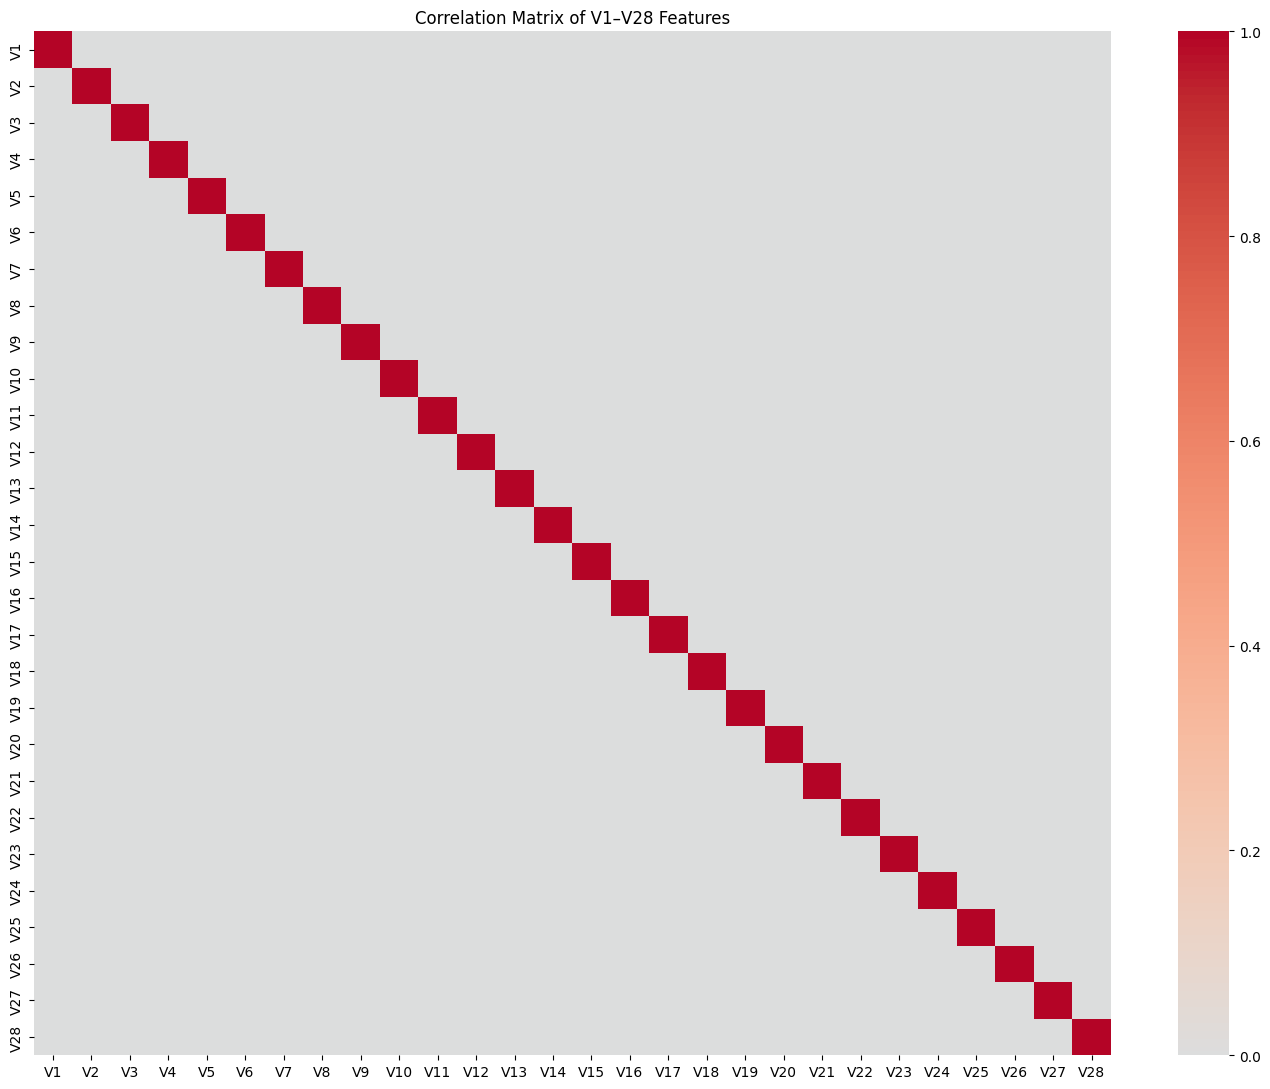

Duplicate rows by class:


col_0,Duplicate Rows
Class,
0,1822
1,32



Number of modeling features: 30
Target: Class

Features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Time', 'Amount']


In [19]:
# ==========================================
# STEP 1: Calculate V-feature correlations
# ==========================================

v_features = [f'V{i}' for i in range(1, 29)]

corr_matrix = df[v_features].corr()


# ==========================================
# STEP 2: Extract only unique feature pairs
# ==========================================

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

feature_pairs = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Top 15 correlations between V-features:")
display(feature_pairs.head(15))


# ==========================================
# STEP 3: Check highly correlated pairs
# ==========================================

high_corr = feature_pairs[abs(feature_pairs) > 0.5]

print("\nFeature pairs with |correlation| > 0.5:")
display(high_corr)


# ==========================================
# STEP 4: Visualize correlation matrix
# ==========================================

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of V1–V28 Features')
plt.tight_layout()
plt.show()


# ==========================================
# STEP 5: Check duplicate rows by class
# ==========================================

duplicate_class = pd.crosstab(
    duplicate_rows['Class'],
    columns='Duplicate Rows'
)

print("Duplicate rows by class:")
display(duplicate_class)


# ==========================================
# STEP 6: Create a clean feature list
# ==========================================

features = v_features + ['Time', 'Amount']
target = 'Class'

print("\nNumber of modeling features:", len(features))
print("Target:", target)
print("\nFeatures:")
print(features)

In [20]:
# ==========================================
# STEP 1: Check current dataframe columns
# ==========================================

print("Current number of columns:", df.shape[1])
print("\nCurrent columns:")
print(df.columns.tolist())


# ==========================================
# STEP 2: Remove temporary EDA columns
# ==========================================

eda_columns = ['Time_Hours', 'Day', 'Hour', 'Amount_Bin']

df_model = df.drop(columns=eda_columns)

print("\nColumns after removing temporary EDA features:")
print(df_model.shape)


# ==========================================
# STEP 3: Compare original vs duplicate-free
# ==========================================

df_no_duplicates = df_model.drop_duplicates()

print("\nOriginal rows:", len(df_model))
print("Rows after removing duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df_model) - len(df_no_duplicates))


# ==========================================
# STEP 4: Compare class distribution
# ==========================================

print("\nClass distribution BEFORE removing duplicates:")
print(df_model['Class'].value_counts())

print("\nClass distribution AFTER removing duplicates:")
print(df_no_duplicates['Class'].value_counts())


# ==========================================
# STEP 5: Compare fraud percentage
# ==========================================

print("\nFraud percentage BEFORE removing duplicates:")
print(df_model['Class'].mean() * 100)

print("\nFraud percentage AFTER removing duplicates:")
print(df_no_duplicates['Class'].mean() * 100)


# ==========================================
# STEP 6: Check duplicate fraud records
# ==========================================

fraud_duplicates = df_model[
    df_model.duplicated(keep=False) &
    (df_model['Class'] == 1)
]

print("\nFraud rows involved in duplicates:", len(fraud_duplicates))

display(fraud_duplicates)

Current number of columns: 35

Current columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Time_Hours', 'Day', 'Hour', 'Amount_Bin']

Columns after removing temporary EDA features:
(284807, 31)

Original rows: 284807
Rows after removing duplicates: 283726
Rows removed: 1081

Class distribution BEFORE removing duplicates:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution AFTER removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud percentage BEFORE removing duplicates:
0.1727485630620034

Fraud percentage AFTER removing duplicates:
0.1667101358352777

Fraud rows involved in duplicates: 32


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102441,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141257,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141259,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1


In [21]:
# ==========================================
# STEP 1: Create clean dataset
# ==========================================

df_clean = df_model.drop_duplicates().copy()

print("Clean dataset shape:", df_clean.shape)


# ==========================================
# STEP 2: Verify missing values
# ==========================================

print("\nTotal missing values:")
print(df_clean.isnull().sum().sum())


# ==========================================
# STEP 3: Verify duplicate rows
# ==========================================

print("\nRemaining duplicate rows:")
print(df_clean.duplicated().sum())


# ==========================================
# STEP 4: Check final class distribution
# ==========================================

print("\nFinal class distribution:")
print(df_clean['Class'].value_counts())


# ==========================================
# STEP 5: Check final class percentages
# ==========================================

print("\nFinal class distribution (%):")
print(
    df_clean['Class']
    .value_counts(normalize=True)
    .mul(100)
)


# ==========================================
# STEP 6: Create X and y
# ==========================================

features = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']

X = df_clean[features]
y = df_clean['Class']

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Clean dataset shape: (283726, 31)

Total missing values:
0

Remaining duplicate rows:
0

Final class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Final class distribution (%):
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Feature matrix shape: (283726, 30)
Target shape: (283726,)

Feature columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Time', 'Amount']


In [22]:
# ============================================================
# STEP 1: Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


# ============================================================
# STEP 2: Check class distribution in training data
# ============================================================

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTraining class distribution (%):")
print(y_train.value_counts(normalize=True).mul(100))


# ============================================================
# STEP 3: Check class distribution in testing data
# ============================================================

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTesting class distribution (%):")
print(y_test.value_counts(normalize=True).mul(100))


# ============================================================
# STEP 4: Create StandardScaler
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)


# ============================================================
# STEP 5: Convert scaled arrays back to DataFrames
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


# ============================================================
# STEP 6: Final verification
# ============================================================

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nTraining feature means after scaling:")
print(X_train_scaled.mean().round(3).head())

print("\nTraining feature standard deviations after scaling:")
print(X_train_scaled.std().round(3).head())

Training set shape: (226980, 30)
Testing set shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Training class distribution (%):
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Testing class distribution (%):
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64

Scaled training shape: (226980, 30)
Scaled testing shape: (56746, 30)

Training feature means after scaling:
V1    0.0
V2   -0.0
V3    0.0
V4   -0.0
V5    0.0
dtype: float64

Training feature standard deviations after scaling:
V1    1.0
V2    1.0
V3    1.0
V4    1.0
V5    1.0
dtype: float64


In [23]:
# ============================================================
# STEP 1: Import SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE


# ============================================================
# STEP 2: Create SMOTE
# ============================================================

smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)


# ============================================================
# STEP 3: Apply SMOTE ONLY to training data
# ============================================================

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# ============================================================
# STEP 4: Check new training shape
# ============================================================

print("Original training shape:", X_train_scaled.shape)
print("SMOTE training shape:", X_train_smote.shape)


# ============================================================
# STEP 5: Check class distribution after SMOTE
# ============================================================

print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())


# ============================================================
# STEP 6: Check class percentages
# ============================================================

print("\nClass distribution AFTER SMOTE (%):")
print(
    y_train_smote.value_counts(normalize=True).mul(100)
)

Original training shape: (226980, 30)
SMOTE training shape: (339903, 30)

Class distribution BEFORE SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0    226602
1    113301
Name: count, dtype: int64

Class distribution AFTER SMOTE (%):
Class
0    66.666667
1    33.333333
Name: proportion, dtype: float64


In [24]:
# ============================================================
# STEP 1: Import SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE


# ============================================================
# STEP 2: Create SMOTE
# ============================================================

smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)


# ============================================================
# STEP 3: Apply SMOTE ONLY to training data
# ============================================================

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# ============================================================
# STEP 4: Check new training shape
# ============================================================

print("Original training shape:", X_train_scaled.shape)
print("SMOTE training shape:", X_train_smote.shape)


# ============================================================
# STEP 5: Check class distribution after SMOTE
# ============================================================

print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())


# ============================================================
# STEP 6: Check class percentages
# ============================================================

print("\nClass distribution AFTER SMOTE (%):")
print(
    y_train_smote.value_counts(normalize=True).mul(100)
)

Original training shape: (226980, 30)
SMOTE training shape: (339903, 30)

Class distribution BEFORE SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0    226602
1    113301
Name: count, dtype: int64

Class distribution AFTER SMOTE (%):
Class
0    66.666667
1    33.333333
Name: proportion, dtype: float64


In [25]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# STEP 1: Create model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# STEP 2: Train model
logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression training completed!")


# STEP 3: Predictions on untouched test data
y_pred = logistic_model.predict(X_test_scaled)

y_pred_proba = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]


# STEP 4: Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)


# STEP 5: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# STEP 6: Calculate important metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)


# STEP 7: Display metrics
print("\nModel Performance:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

Logistic Regression training completed!

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9878    0.9938     56651
       Fraud     0.1074    0.8737    0.1912        95

    accuracy                         0.9876     56746
   macro avg     0.5536    0.9308    0.5925     56746
weighted avg     0.9983    0.9876    0.9924     56746


Confusion Matrix:
[[55961   690]
 [   12    83]]

Model Performance:
Precision : 0.1074
Recall    : 0.8737
F1-Score  : 0.1912
ROC-AUC   : 0.9644
PR-AUC    : 0.6532


In [26]:
# ============================================================
# MODEL 2: RANDOM FOREST - LIGHT VERSION
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest training completed!")

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)

# Metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Performance:")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")
print(f"PR-AUC    : {pr_auc_rf:.4f}")

Starting Random Forest training...
Random Forest training completed!

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9997    0.9997     56651
       Fraud     0.8111    0.7684    0.7892        95

    accuracy                         0.9993     56746
   macro avg     0.9054    0.8841    0.8944     56746
weighted avg     0.9993    0.9993    0.9993     56746


Confusion Matrix:
[[56634    17]
 [   22    73]]

Random Forest Performance:
Precision : 0.8111
Recall    : 0.7684
F1-Score  : 0.7892
ROC-AUC   : 0.9768
PR-AUC    : 0.7974


Top 15 Most Important Features:
Feature  Importance
    V14    0.228774
    V17    0.129076
    V10    0.123639
     V4    0.087156
    V12    0.079758
    V11    0.062435
    V16    0.055969
     V3    0.047259
     V7    0.028957
     V2    0.025518
     V9    0.015809
    V21    0.011274
    V19    0.009852
     V8    0.009702
    V18    0.008624


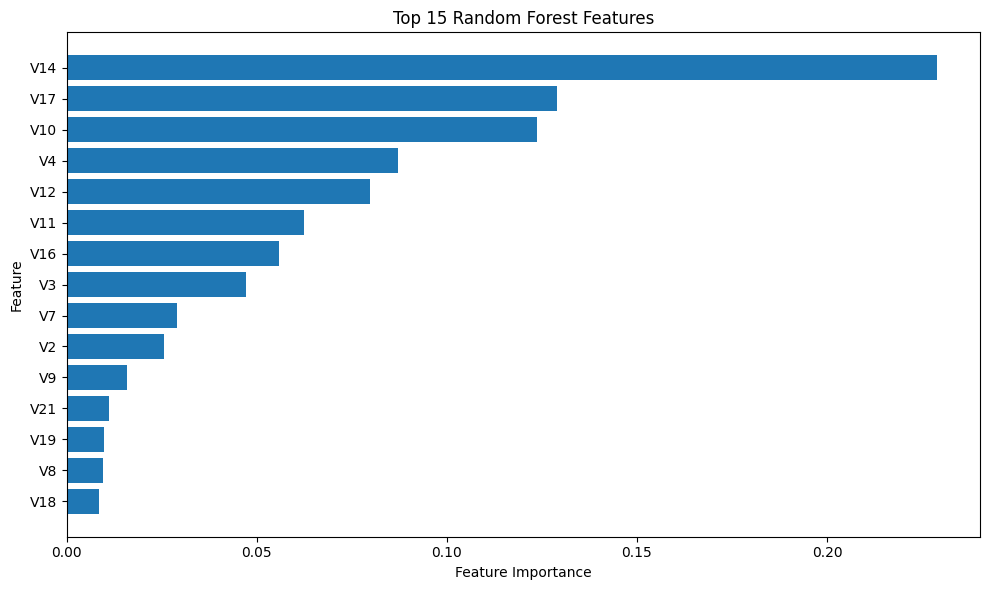

In [27]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': rf_model.feature_importances_
})

# STEP 2: Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# STEP 3: Display top 15 features
print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))


# ============================================================
# STEP 4: Plot top 15 features
# ============================================================

top_features = feature_importance.head(15).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_rf
    ]
})

print("Model Comparison:")
display(model_comparison.round(4))

Model Comparison:


,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.1074,0.8737,0.1912,0.9644,0.6532
1,Random Forest,0.8111,0.7684,0.7892,0.9768,0.7974


In [29]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [30]:
get_ipython().run_line_magic('pip', 'install shap')

Note: you may need to restart the kernel to use updated packages.


In [31]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

import shap

# Create TreeExplainer for our Random Forest
explainer = shap.TreeExplainer(rf_model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [32]:
# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

# Use a sample of the test set for faster SHAP calculation
X_shap = X_test_scaled.sample(
    n=min(2000, len(X_test_scaled)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully!")
print("SHAP output type:", type(shap_values))

SHAP sample shape: (2000, 30)
SHAP values calculated successfully!
SHAP output type: <class 'numpy.ndarray'>


In [33]:
# ============================================================
# CALCULATE SHAP VALUES
# ============================================================

# Use 2,000 test transactions for faster SHAP calculation
X_shap = X_test_scaled.sample(
    n=min(2000, len(X_test_scaled)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully!")
print("SHAP output type:", type(shap_values))

SHAP sample shape: (2000, 30)
SHAP values calculated successfully!
SHAP output type: <class 'numpy.ndarray'>


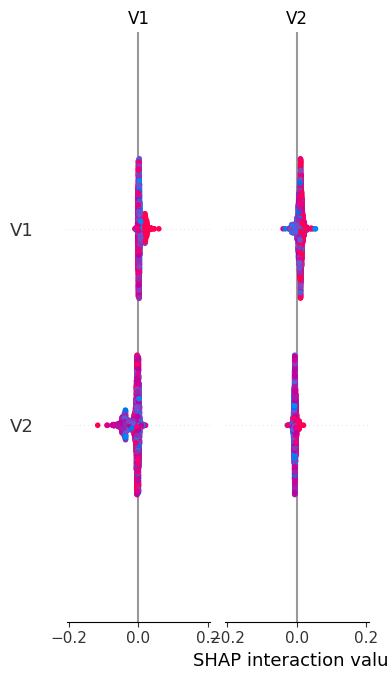

In [34]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

In [35]:
# ============================================================
# FIX SHAP VALUES FOR FRAUD CLASS
# ============================================================

print("Original SHAP shape:", shap_values.shape)

# Select SHAP values for Class 1 (Fraud)
shap_values_fraud = shap_values[:, :, 1]

print("Fraud SHAP shape:", shap_values_fraud.shape)

Original SHAP shape: (2000, 30, 2)
Fraud SHAP shape: (2000, 30)


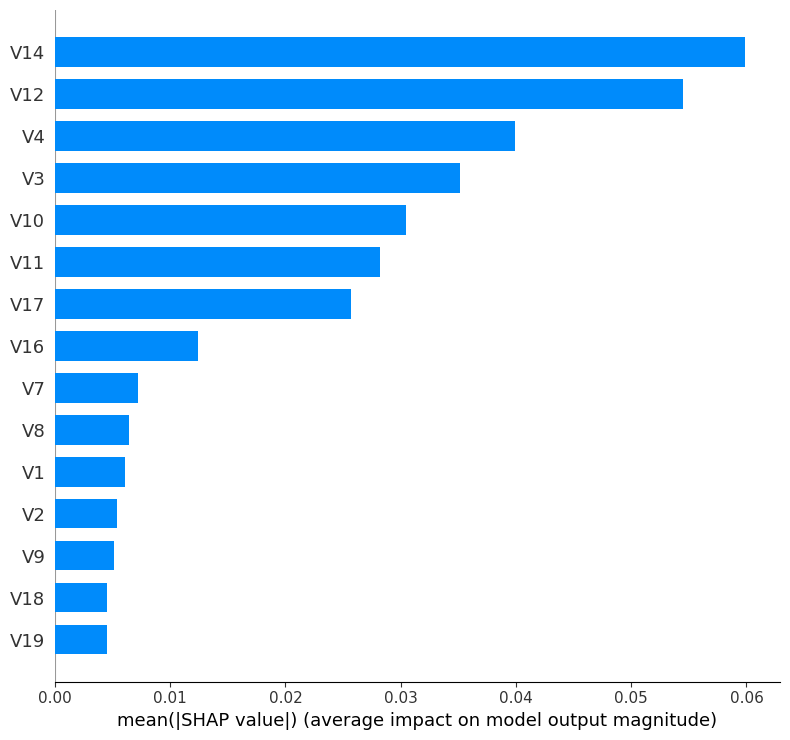

In [36]:
# ============================================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values_fraud,
    X_shap,
    plot_type="bar",
    max_display=15
)

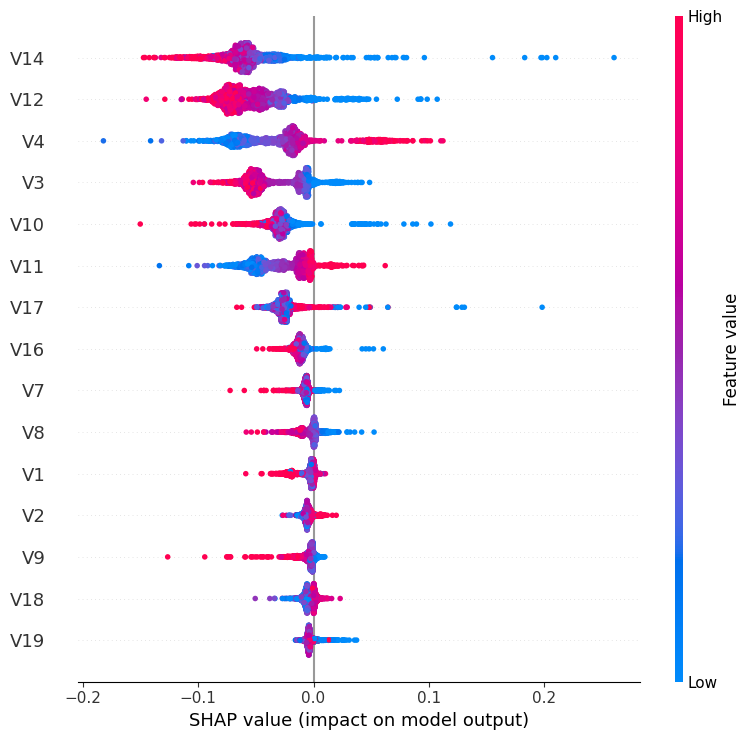

In [37]:
# ============================================================
# SHAP SUMMARY / BEESWARM PLOT
# ============================================================

shap.summary_plot(
    shap_values_fraud,
    X_shap,
    max_display=15
)

In [38]:
# ============================================================
# THRESHOLD ANALYSIS FOR RANDOM FOREST
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Thresholds to test
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probability into prediction
    y_pred_threshold = (
        y_pred_proba_rf >= threshold
    ).astype(int)

    precision_t = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall_t = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1_t = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_t,
        "Recall": recall_t,
        "F1-Score": f1_t
    })


# Create results table
threshold_df = pd.DataFrame(threshold_results)

print("Threshold Performance:")
display(
    threshold_df.round(4)
)

Threshold Performance:


,Threshold,Precision,Recall,F1-Score
0,0.10,0.1081,0.8526,0.1919
1,0.15,0.2041,0.8316,0.3278
2,0.20,0.3158,0.8211,0.4561
3,0.25,0.4425,0.8105,0.5725
4,0.30,0.5580,0.8105,0.6609
5,0.35,0.6937,0.8105,0.7476
6,0.40,0.7379,0.8000,0.7677
7,0.45,0.7629,0.7789,0.7708
8,0.50,0.8111,0.7684,0.7892
9,0.55,0.8372,0.7579,0.7956


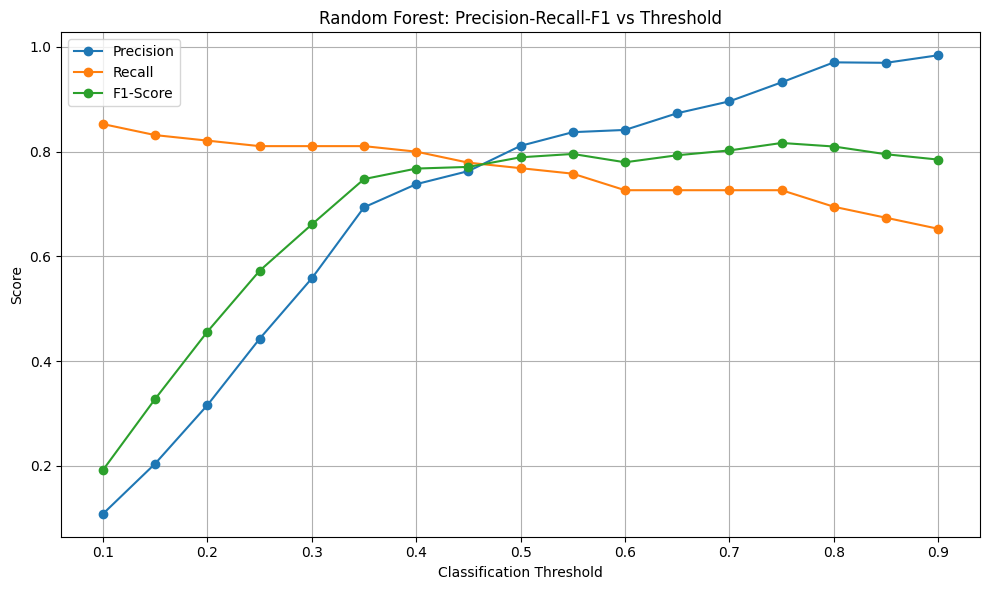

In [39]:
# ============================================================
# PRECISION-RECALL-THRESHOLD CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Precision-Recall-F1 vs Threshold")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# BEST THRESHOLD RESULT
# ============================================================

best_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Best threshold based on F1-score:")
print(best_row)

Best threshold based on F1-score:
Threshold    0.750000
Precision    0.932432
Recall       0.726316
F1-Score     0.816568
Name: 13, dtype: float64


In [41]:
# ============================================================
# VALIDATION-BASED THRESHOLD SELECTION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd


# ============================================================
# STEP 1: Split original training data
# ============================================================

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Main training shape:", X_train_main.shape)
print("Validation shape:", X_val.shape)

print("\nMain training class distribution:")
print(y_train_main.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


# ============================================================
# STEP 2: Scale using ONLY main training data
# ============================================================

validation_scaler = StandardScaler()

X_train_main_scaled = validation_scaler.fit_transform(
    X_train_main
)

X_val_scaled = validation_scaler.transform(
    X_val
)


# ============================================================
# STEP 3: Apply SMOTE ONLY to main training data
# ============================================================

validation_smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)

X_train_main_smote, y_train_main_smote = (
    validation_smote.fit_resample(
        X_train_main_scaled,
        y_train_main
    )
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_main_smote).value_counts())


# ============================================================
# STEP 4: Train validation Random Forest
# ============================================================

validation_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("\nStarting validation Random Forest training...")

validation_rf.fit(
    X_train_main_smote,
    y_train_main_smote
)

print("Validation Random Forest training completed!")


# ============================================================
# STEP 5: Get validation probabilities
# ============================================================

y_val_proba = validation_rf.predict_proba(
    X_val_scaled
)[:, 1]


# ============================================================
# STEP 6: Find best threshold using VALIDATION data
# ============================================================

thresholds = np.arange(0.10, 0.91, 0.05)

validation_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_proba >= threshold
    ).astype(int)

    precision_val = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall_val = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1_val = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "F1-Score": f1_val
    })


validation_threshold_df = pd.DataFrame(
    validation_results
)


# ============================================================
# STEP 7: Display validation results
# ============================================================

print("\nValidation Threshold Results:")

display(
    validation_threshold_df.round(4)
)


# ============================================================
# STEP 8: Select best threshold
# ============================================================

best_validation_row = validation_threshold_df.loc[
    validation_threshold_df["F1-Score"].idxmax()
]

print("\nBest validation threshold:")
print(best_validation_row)

Main training shape: (181584, 30)
Validation shape: (45396, 30)

Main training class distribution:
Class
0    181282
1       302
Name: count, dtype: int64

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64

After SMOTE:
Class
0    181282
1     90641
Name: count, dtype: int64

Starting validation Random Forest training...
Validation Random Forest training completed!

Validation Threshold Results:


,Threshold,Precision,Recall,F1-Score
0,0.10,0.1472,0.8947,0.2528
1,0.15,0.2627,0.8816,0.4048
2,0.20,0.3976,0.8684,0.5455
3,0.25,0.5242,0.8553,0.6500
4,0.30,0.6500,0.8553,0.7386
5,0.35,0.7222,0.8553,0.7831
6,0.40,0.7927,0.8553,0.8228
7,0.45,0.8333,0.8553,0.8442
8,0.50,0.8442,0.8553,0.8497
9,0.55,0.8533,0.8421,0.8477



Best validation threshold:
Threshold    0.750000
Precision    0.939394
Recall       0.815789
F1-Score     0.873239
Name: 13, dtype: float64


In [42]:
# ============================================================
# FINAL RANDOM FOREST EVALUATION
# Threshold selected using validation data
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Final threshold selected from validation data
final_threshold = 0.75

# Get fraud probabilities on untouched test set
y_test_proba_final = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

# Apply selected threshold
y_test_pred_final = (
    y_test_proba_final >= final_threshold
).astype(int)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_final = confusion_matrix(
    y_test,
    y_test_pred_final
)

print("Final Confusion Matrix:")
print(cm_final)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=["Legitimate", "Fraud"],
        digits=4
    )
)


# ============================================================
# FINAL FRAUD METRICS
# ============================================================

final_precision = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_final
)

final_pr_auc = average_precision_score(
    y_test,
    y_test_proba_final
)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("\nFINAL RANDOM FOREST PERFORMANCE")
print("--------------------------------")
print(f"Threshold : {final_threshold:.2f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")

Final Confusion Matrix:
[[56646     5]
 [   26    69]]

Final Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9995    0.9999    0.9997     56651
       Fraud     0.9324    0.7263    0.8166        95

    accuracy                         0.9995     56746
   macro avg     0.9660    0.8631    0.9081     56746
weighted avg     0.9994    0.9995    0.9994     56746


FINAL RANDOM FOREST PERFORMANCE
--------------------------------
Threshold : 0.75
Precision : 0.9324
Recall    : 0.7263
F1-Score  : 0.8166
ROC-AUC   : 0.9768
PR-AUC    : 0.7974


In [43]:
# ============================================================
# FRAUD RISK SCORING SYSTEM
# ============================================================

def calculate_risk(transaction):

    # Convert transaction into DataFrame
    transaction_df = pd.DataFrame(
        [transaction],
        columns=features
    )

    # Scale using the scaler from the original training data
    transaction_scaled = scaler.transform(
        transaction_df
    )

    # Get fraud probability
    fraud_probability = rf_model.predict_proba(
        transaction_scaled
    )[0, 1]

    # Apply final threshold
    prediction = int(
        fraud_probability >= final_threshold
    )

    # Determine risk level
    if fraud_probability >= 0.75:
        risk_level = "HIGH"
    elif fraud_probability >= 0.30:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "Fraud Probability": fraud_probability,
        "Risk Score": fraud_probability * 100,
        "Risk Level": risk_level,
        "Prediction": prediction
    }


print("Risk scoring function created successfully!")

Risk scoring function created successfully!


In [44]:
# ============================================================
# TEST THE FRAUD RISK SCORING SYSTEM
# ============================================================

# STEP 1: Get one actual legitimate transaction
legit_index = y_test[y_test == 0].index[0]

legit_transaction = X_test.loc[
    legit_index
].values


# STEP 2: Get one actual fraud transaction
fraud_index = y_test[y_test == 1].index[0]

fraud_transaction = X_test.loc[
    fraud_index
].values


# STEP 3: Calculate risk for legitimate transaction
legit_result = calculate_risk(
    legit_transaction
)


# STEP 4: Calculate risk for fraud transaction
fraud_result = calculate_risk(
    fraud_transaction
)


# STEP 5: Display results
print("=" * 50)
print("LEGITIMATE TRANSACTION")
print("=" * 50)

for key, value in legit_result.items():
    if key == "Fraud Probability":
        print(f"{key}: {value:.4f}")
    elif key == "Risk Score":
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")


print("\n" + "=" * 50)
print("ACTUAL FRAUD TRANSACTION")
print("=" * 50)

for key, value in fraud_result.items():
    if key == "Fraud Probability":
        print(f"{key}: {value:.4f}")
    elif key == "Risk Score":
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")

LEGITIMATE TRANSACTION
Fraud Probability: 0.0050
Risk Score: 0.50%
Risk Level: LOW
Prediction: 0

ACTUAL FRAUD TRANSACTION
Fraud Probability: 0.9998
Risk Score: 99.98%
Risk Level: HIGH
Prediction: 1


In [45]:
# ============================================================
# INDIVIDUAL TRANSACTION SHAP EXPLANATION
# ============================================================

# Create DataFrame for the fraud transaction
fraud_transaction_df = pd.DataFrame(
    [fraud_transaction],
    columns=features
)

# Scale the transaction using our training scaler
fraud_transaction_scaled = scaler.transform(
    fraud_transaction_df
)

# Calculate SHAP values for this transaction
fraud_shap_values = explainer.shap_values(
    pd.DataFrame(
        fraud_transaction_scaled,
        columns=features
    )
)

# Select Fraud class (Class 1)
if len(fraud_shap_values.shape) == 3:
    fraud_shap_values = fraud_shap_values[:, :, 1]

print("SHAP explanation calculated!")
print("SHAP shape:", fraud_shap_values.shape)

SHAP explanation calculated!
SHAP shape: (1, 30)


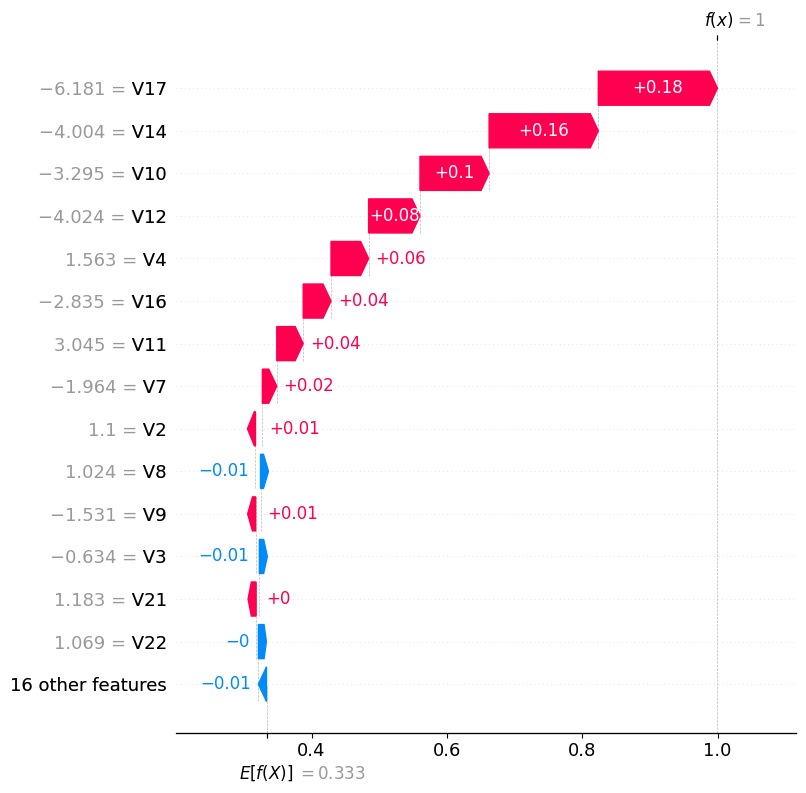

In [46]:
# ============================================================
# INDIVIDUAL SHAP WATERFALL PLOT
# ============================================================

# Create SHAP Explanation object
fraud_explanation = shap.Explanation(
    values=fraud_shap_values[0],
    base_values=explainer.expected_value[1],
    data=fraud_transaction_scaled[0],
    feature_names=features
)

# Display waterfall plot
shap.plots.waterfall(
    fraud_explanation,
    max_display=15
)

In [47]:
# ============================================================
# FINAL MODEL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Classification Threshold"
    ],
    "Random Forest": [
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc,
        final_threshold
    ]
})

print("Final Random Forest Results:")
display(
    final_results.round(4)
)

Final Random Forest Results:


,Metric,Random Forest
0,Precision,0.9324
1,Recall,0.7263
2,F1-Score,0.8166
3,ROC-AUC,0.9768
4,PR-AUC,0.7974
5,Classification Threshold,0.7500


In [48]:
# ============================================================
# RISK ANALYTICS
# ============================================================

# STEP 1: Basic transaction statistics

total_transactions = len(df_clean)

total_fraud = (df_clean["Class"] == 1).sum()

total_legitimate = (df_clean["Class"] == 0).sum()

fraud_rate = (
    total_fraud / total_transactions
) * 100

print("TRANSACTION OVERVIEW")
print("-" * 40)
print(f"Total Transactions : {total_transactions:,}")
print(f"Legitimate         : {total_legitimate:,}")
print(f"Fraud              : {total_fraud:,}")
print(f"Fraud Rate         : {fraud_rate:.4f}%")


# ============================================================
# STEP 2: Transaction amount statistics
# ============================================================

total_amount = df_clean["Amount"].sum()

fraud_amount = df_clean.loc[
    df_clean["Class"] == 1,
    "Amount"
].sum()

legitimate_amount = df_clean.loc[
    df_clean["Class"] == 0,
    "Amount"
].sum()

print("\nTRANSACTION AMOUNT")
print("-" * 40)
print(f"Total Amount       : ${total_amount:,.2f}")
print(f"Legitimate Amount  : ${legitimate_amount:,.2f}")
print(f"Fraud Amount       : ${fraud_amount:,.2f}")


# ============================================================
# STEP 3: Average transaction amounts
# ============================================================

avg_legitimate = df_clean.loc[
    df_clean["Class"] == 0,
    "Amount"
].mean()

avg_fraud = df_clean.loc[
    df_clean["Class"] == 1,
    "Amount"
].mean()

median_legitimate = df_clean.loc[
    df_clean["Class"] == 0,
    "Amount"
].median()

median_fraud = df_clean.loc[
    df_clean["Class"] == 1,
    "Amount"
].median()

print("\nAVERAGE TRANSACTION AMOUNT")
print("-" * 40)
print(f"Legitimate Mean   : ${avg_legitimate:.2f}")
print(f"Fraud Mean        : ${avg_fraud:.2f}")
print(f"Legitimate Median : ${median_legitimate:.2f}")
print(f"Fraud Median      : ${median_fraud:.2f}")


# ============================================================
# STEP 4: Fraud rate by amount range
# ============================================================

amount_bins = [
    -0.01,
    1,
    10,
    50,
    100,
    500,
    1000,
    float("inf")
]

amount_labels = [
    "0–1",
    "1–10",
    "10–50",
    "50–100",
    "100–500",
    "500–1000",
    "1000+"
]

amount_analysis = df_clean.copy()

amount_analysis["Amount_Range"] = pd.cut(
    amount_analysis["Amount"],
    bins=amount_bins,
    labels=amount_labels
)

amount_risk = (
    amount_analysis
    .groupby("Amount_Range", observed=False)["Class"]
    .agg(
        Transactions="count",
        Fraud="sum",
        Fraud_Rate="mean"
    )
)

amount_risk["Fraud_Rate"] = (
    amount_risk["Fraud_Rate"] * 100
)

print("\nFRAUD RATE BY AMOUNT RANGE")
print("-" * 40)

display(
    amount_risk.round(4)
)


# ============================================================
# STEP 5: Overall fraud percentage
# ============================================================

print("\nFinal fraud rate:")
print(f"{fraud_rate:.4f}%")

TRANSACTION OVERVIEW
----------------------------------------
Total Transactions : 283,726
Legitimate         : 283,253
Fraud              : 473
Fraud Rate         : 0.1667%

TRANSACTION AMOUNT
----------------------------------------
Total Amount       : $25,102,001.68
Legitimate Amount  : $25,043,410.29
Fraud Amount       : $58,591.39

AVERAGE TRANSACTION AMOUNT
----------------------------------------
Legitimate Mean   : $88.41
Fraud Mean        : $123.87
Legitimate Median : $22.00
Fraud Median      : $9.82

FRAUD RATE BY AMOUNT RANGE
----------------------------------------


,Transactions,Fraud,Fraud_Rate
Amount_Range,,,
0–1,30331,171,0.5638
1–10,69490,67,0.0964
10–50,90327,55,0.0609
50–100,37179,55,0.1479
100–500,47290,91,0.1924
500–1000,6174,25,0.4049
1000+,2935,9,0.3066



Final fraud rate:
0.1667%


In [49]:
# ============================================================
# TIME-BASED FRAUD RISK ANALYSIS
# ============================================================

# STEP 1: Create temporary time features
time_analysis = df_clean.copy()

time_analysis["Time_Hours"] = time_analysis["Time"] / 3600

time_analysis["Hour"] = (
    (time_analysis["Time"] // 3600) % 24
).astype(int)


# ============================================================
# STEP 2: Calculate hourly transaction statistics
# ============================================================

hourly_risk = (
    time_analysis
    .groupby("Hour")["Class"]
    .agg(
        Transactions="count",
        Fraud="sum",
        Fraud_Rate="mean"
    )
)

hourly_risk["Fraud_Rate"] = (
    hourly_risk["Fraud_Rate"] * 100
)


# ============================================================
# STEP 3: Display hourly analysis
# ============================================================

print("FRAUD RISK BY HOUR")
print("-" * 40)

display(
    hourly_risk.round(4)
)


# ============================================================
# STEP 4: Find highest-risk hours
# ============================================================

top_hours = hourly_risk.sort_values(
    by="Fraud_Rate",
    ascending=False
).head(5)

print("\nTOP 5 HOURS BY FRAUD RATE")
print("-" * 40)

display(
    top_hours.round(4)
)


# ============================================================
# STEP 5: Find hours with most fraud transactions
# ============================================================

most_fraud_hours = hourly_risk.sort_values(
    by="Fraud",
    ascending=False
).head(5)

print("\nTOP 5 HOURS BY FRAUD COUNT")
print("-" * 40)

display(
    most_fraud_hours
)


# ============================================================
# STEP 6: Summary
# ============================================================

highest_risk_hour = hourly_risk["Fraud_Rate"].idxmax()
highest_risk_rate = hourly_risk["Fraud_Rate"].max()

print("\nHighest observed fraud-rate hour:")
print(
    f"Hour {highest_risk_hour}: "
    f"{highest_risk_rate:.4f}%"
)

FRAUD RISK BY HOUR
----------------------------------------


,Transactions,Fraud,Fraud_Rate
Hour,,,
0,7647,6,0.0785
1,4208,10,0.2376
2,3308,48,1.4510
3,3487,17,0.4875
4,2204,23,1.0436
5,2988,11,0.3681
6,4082,9,0.2205
7,7233,23,0.3180
8,10232,9,0.0880



TOP 5 HOURS BY FRAUD RATE
----------------------------------------


,Transactions,Fraud,Fraud_Rate
Hour,,,
2,3308,48,1.4510
4,2204,23,1.0436
3,3487,17,0.4875
5,2988,11,0.3681
7,7233,23,0.3180



TOP 5 HOURS BY FRAUD COUNT
----------------------------------------


,Transactions,Fraud,Fraud_Rate
Hour,,,
11,16781,53,0.315833
2,3308,48,1.451028
17,16130,28,0.173590
18,16959,28,0.165104
15,16374,26,0.158788



Highest observed fraud-rate hour:
Hour 2: 1.4510%


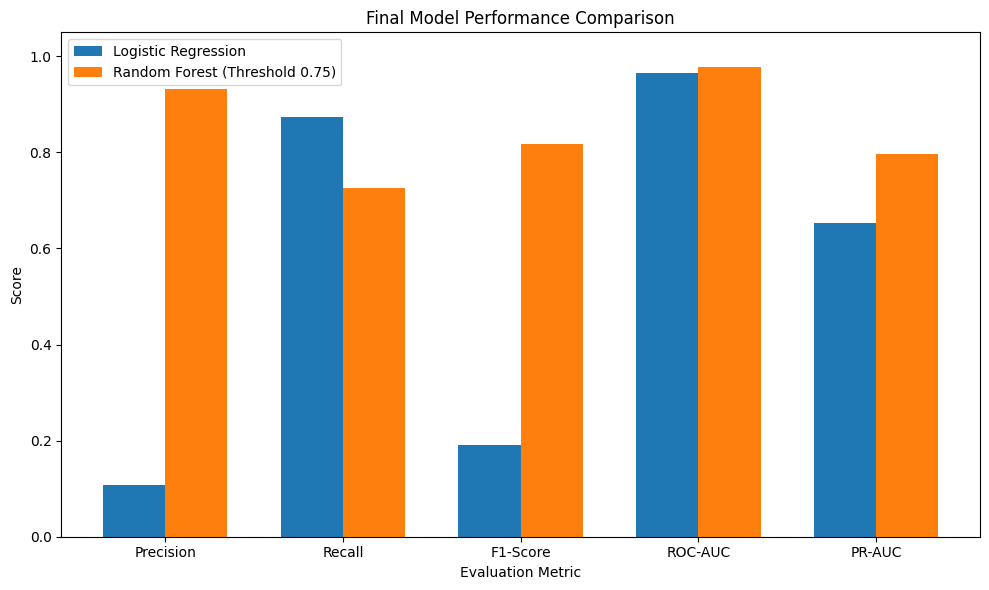

In [51]:
# ============================================================
# MODEL PERFORMANCE VISUALIZATION
# ============================================================

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

logistic_final_scores = [
    precision,
    recall,
    f1,
    roc_auc,
    pr_auc
]

random_forest_final_scores = [
    final_precision,
    final_recall,
    final_f1,
    final_roc_auc,
    final_pr_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    logistic_final_scores,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    random_forest_final_scores,
    width,
    label="Random Forest (Threshold 0.75)"
)

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Final Model Performance Comparison")

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# SQL ANALYTICS SETUP
# ============================================================

import sqlite3

# Create SQLite database
conn = sqlite3.connect("fraud_detection.db")

# Store cleaned dataset in SQLite
df_clean.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully!")
print("Table created: transactions")

SQLite database created successfully!
Table created: transactions


In [53]:
# ============================================================
# VERIFY SQL TABLE
# ============================================================

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

display(tables)

# Check number of rows
row_count = pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_transactions
    FROM transactions;
    """,
    conn
)

display(row_count)

,name
0,transactions


,total_transactions
0,283726


In [54]:
# ============================================================
# SQL: FRAUD SUMMARY
# ============================================================

fraud_summary = pd.read_sql_query(
    """
    SELECT
        Class,
        COUNT(*) AS Transactions,
        ROUND(
            100.0 * COUNT(*) /
            (SELECT COUNT(*) FROM transactions),
            4
        ) AS Percentage
    FROM transactions
    GROUP BY Class
    ORDER BY Class;
    """,
    conn
)

display(fraud_summary)

,Class,Transactions,Percentage
0,0,283253,99.8333
1,1,473,0.1667


In [55]:
# ============================================================
# SQL: TRANSACTION AMOUNT BY CLASS
# ============================================================

amount_summary = pd.read_sql_query(
    """
    SELECT
        Class,
        COUNT(*) AS Transactions,
        ROUND(AVG(Amount), 2) AS Average_Amount,
        ROUND(MIN(Amount), 2) AS Minimum_Amount,
        ROUND(MAX(Amount), 2) AS Maximum_Amount
    FROM transactions
    GROUP BY Class;
    """,
    conn
)

display(amount_summary)

,Class,Transactions,Average_Amount,Minimum_Amount,Maximum_Amount
0,0,283253,88.41,0.0,25691.16
1,1,473,123.87,0.0,2125.87


In [56]:
# ============================================================
# SQL: TOP 10 HIGHEST-VALUE FRAUD TRANSACTIONS
# ============================================================

top_fraud = pd.read_sql_query(
    """
    SELECT
        Time,
        Amount,
        Class
    FROM transactions
    WHERE Class = 1
    ORDER BY Amount DESC
    LIMIT 10;
    """,
    conn
)

display(top_fraud)

,Time,Amount,Class
0,122608.0,2125.87,1
1,9064.0,1809.68,1
2,154278.0,1504.93,1
3,62467.0,1402.16,1
4,59011.0,1389.56,1
5,65385.0,1354.25,1
6,133184.0,1335.00,1
7,18088.0,1218.89,1
8,154309.0,1096.99,1
9,147501.0,996.27,1


In [57]:
# ============================================================
# ADVANCED SQL FRAUD ANALYTICS
# ============================================================

# ============================================================
# QUERY 1: FRAUD RATE BY AMOUNT RANGE
# ============================================================

amount_sql = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN Amount <= 1 THEN '0-1'
            WHEN Amount <= 10 THEN '1-10'
            WHEN Amount <= 50 THEN '10-50'
            WHEN Amount <= 100 THEN '50-100'
            WHEN Amount <= 500 THEN '100-500'
            WHEN Amount <= 1000 THEN '500-1000'
            ELSE '1000+'
        END AS Amount_Range,

        COUNT(*) AS Transactions,

        SUM(Class) AS Fraud,

        ROUND(
            100.0 * SUM(Class) / COUNT(*),
            4
        ) AS Fraud_Rate

    FROM transactions

    GROUP BY Amount_Range

    ORDER BY
        CASE Amount_Range
            WHEN '0-1' THEN 1
            WHEN '1-10' THEN 2
            WHEN '10-50' THEN 3
            WHEN '50-100' THEN 4
            WHEN '100-500' THEN 5
            WHEN '500-1000' THEN 6
            WHEN '1000+' THEN 7
        END;
    """,
    conn
)

print("1. FRAUD RATE BY AMOUNT RANGE")
display(amount_sql)


# ============================================================
# QUERY 2: FRAUD RATE BY HOUR
# ============================================================

hour_sql = pd.read_sql_query(
    """
    SELECT
        CAST((Time / 3600) AS INTEGER) % 24 AS Hour,

        COUNT(*) AS Transactions,

        SUM(Class) AS Fraud,

        ROUND(
            100.0 * SUM(Class) / COUNT(*),
            4
        ) AS Fraud_Rate

    FROM transactions

    GROUP BY Hour

    ORDER BY Fraud_Rate DESC;
    """,
    conn
)

print("\n2. FRAUD RATE BY HOUR")
display(hour_sql)


# ============================================================
# QUERY 3: TOP 10 HOURS BY FRAUD COUNT
# ============================================================

fraud_count_sql = pd.read_sql_query(
    """
    SELECT
        CAST((Time / 3600) AS INTEGER) % 24 AS Hour,

        COUNT(*) AS Transactions,

        SUM(Class) AS Fraud

    FROM transactions

    GROUP BY Hour

    ORDER BY Fraud DESC

    LIMIT 10;
    """,
    conn
)

print("\n3. TOP 10 HOURS BY FRAUD COUNT")
display(fraud_count_sql)


# ============================================================
# QUERY 4: CLASS-WISE AMOUNT ANALYSIS
# ============================================================

class_amount_sql = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN Class = 0 THEN 'Legitimate'
            ELSE 'Fraud'
        END AS Transaction_Type,

        COUNT(*) AS Transactions,

        ROUND(SUM(Amount), 2) AS Total_Amount,

        ROUND(AVG(Amount), 2) AS Average_Amount,

        ROUND(
            SUM(Amount) / COUNT(*),
            2
        ) AS Average_Per_Transaction

    FROM transactions

    GROUP BY Class

    ORDER BY Class;
    """,
    conn
)

print("\n4. CLASS-WISE AMOUNT ANALYSIS")
display(class_amount_sql)


# ============================================================
# QUERY 5: TOP 10 HIGHEST-VALUE FRAUD TRANSACTIONS
# ============================================================

high_value_fraud_sql = pd.read_sql_query(
    """
    SELECT
        Time,
        ROUND(Amount, 2) AS Amount,
        Class

    FROM transactions

    WHERE Class = 1

    ORDER BY Amount DESC

    LIMIT 10;
    """,
    conn
)

print("\n5. TOP 10 HIGHEST-VALUE FRAUD TRANSACTIONS")
display(high_value_fraud_sql)

1. FRAUD RATE BY AMOUNT RANGE


,Amount_Range,Transactions,Fraud,Fraud_Rate
0,0-1,30331,171,0.5638
1,1-10,69490,67,0.0964
2,10-50,90327,55,0.0609
3,50-100,37179,55,0.1479
4,100-500,47290,91,0.1924
5,500-1000,6174,25,0.4049
6,1000+,2935,9,0.3066



2. FRAUD RATE BY HOUR


,Hour,Transactions,Fraud,Fraud_Rate
0,2,3308,48,1.4510
1,4,2204,23,1.0436
2,3,3487,17,0.4875
3,5,2988,11,0.3681
4,7,7233,23,0.3180
5,11,16781,53,0.3158
6,1,4208,10,0.2376
7,6,4082,9,0.2205
8,17,16130,28,0.1736
9,18,16959,28,0.1651



3. TOP 10 HOURS BY FRAUD COUNT


,Hour,Transactions,Fraud
0,11,16781,53
1,2,3308,48
2,18,16959,28
3,17,16130,28
4,15,16374,26
5,14,16520,23
6,7,7233,23
7,4,2204,23
8,16,16396,22
9,19,15566,19



4. CLASS-WISE AMOUNT ANALYSIS


,Transaction_Type,Transactions,Total_Amount,Average_Amount,Average_Per_Transaction
0,Legitimate,283253,25043410.29,88.41,88.41
1,Fraud,473,58591.39,123.87,123.87



5. TOP 10 HIGHEST-VALUE FRAUD TRANSACTIONS


,Time,Amount,Class
0,122608.0,2125.87,1
1,9064.0,1809.68,1
2,154278.0,1504.93,1
3,62467.0,1402.16,1
4,59011.0,1389.56,1
5,65385.0,1354.25,1
6,133184.0,1335.00,1
7,18088.0,1218.89,1
8,154309.0,1096.99,1
9,147501.0,996.27,1


In [58]:
# ============================================================
# SAVE MODEL ARTIFACTS FOR DEPLOYMENT
# ============================================================

import joblib
import os

# Create model directory
os.makedirs("model_artifacts", exist_ok=True)


# ============================================================
# STEP 1: Save Random Forest
# ============================================================

joblib.dump(
    rf_model,
    "model_artifacts/random_forest_model.pkl"
)


# ============================================================
# STEP 2: Save StandardScaler
# ============================================================

joblib.dump(
    scaler,
    "model_artifacts/scaler.pkl"
)


# ============================================================
# STEP 3: Save feature names
# ============================================================

joblib.dump(
    features,
    "model_artifacts/features.pkl"
)


# ============================================================
# STEP 4: Save final classification threshold
# ============================================================

joblib.dump(
    final_threshold,
    "model_artifacts/threshold.pkl"
)


# ============================================================
# STEP 5: Verify saved files
# ============================================================

print("Model artifacts saved successfully!\n")

for filename in os.listdir("model_artifacts"):
    print("✓", filename)

Model artifacts saved successfully!

✓ features.pkl
✓ random_forest_model.pkl
✓ scaler.pkl
✓ threshold.pkl


In [59]:
get_ipython().run_line_magic('pip', 'install fastapi uvicorn')

Note: you may need to restart the kernel to use updated packages.


In [61]:
# ============================================================
# FASTAPI SETUP — VERIFY MODEL ARTIFACTS
# ============================================================

import os

model_directory = "model_artifacts"

required_files = [
    "random_forest_model.pkl",
    "scaler.pkl",
    "features.pkl",
    "threshold.pkl"
]

print("=" * 60)
print("FASTAPI MODEL ARTIFACT CHECK")
print("=" * 60)

print()

if os.path.exists(model_directory):

    print("✓ model_artifacts folder found")

else:

    print("❌ model_artifacts folder NOT found")


print()

for filename in required_files:

    filepath = os.path.join(
        model_directory,
        filename
    )

    if os.path.exists(filepath):

        size_kb = os.path.getsize(filepath) / 1024

        print(
            f"✓ {filename} "
            f"({size_kb:.1f} KB)"
        )

    else:

        print(
            f"❌ MISSING: {filename}"
        )

print()

print("=" * 60)
print("CHECK COMPLETE")
print("=" * 60)

FASTAPI MODEL ARTIFACT CHECK

✓ model_artifacts folder found

✓ random_forest_model.pkl (4816.8 KB)
✓ scaler.pkl (1.7 KB)
✓ features.pkl (0.2 KB)
✓ threshold.pkl (0.0 KB)

CHECK COMPLETE


In [62]:
# ============================================================
# FASTAPI — STEP 2: CREATE BACKEND
# ============================================================

import os

app_code = r'''
import os
import joblib
import pandas as pd

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "model_artifacts")


# ============================================================
# LOAD MODEL ARTIFACTS
# ============================================================

model = joblib.load(
    os.path.join(MODEL_DIR, "random_forest_model.pkl")
)

scaler = joblib.load(
    os.path.join(MODEL_DIR, "scaler.pkl")
)

features = joblib.load(
    os.path.join(MODEL_DIR, "features.pkl")
)

threshold = joblib.load(
    os.path.join(MODEL_DIR, "threshold.pkl")
)

features = list(features)


# ============================================================
# CREATE FASTAPI APP
# ============================================================

app = FastAPI(
    title="AI-Powered Credit Card Fraud Detection API",
    description="Machine Learning API for fraud risk prediction",
    version="1.0.0"
)


# ============================================================
# INPUT DATA MODEL
# ============================================================

class Transaction(BaseModel):

    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float

    Time: float
    Amount: float


# ============================================================
# HOME ENDPOINT
# ============================================================

@app.get("/")
def home():

    return {
        "message": "AI-Powered Credit Card Fraud Detection API",
        "status": "running",
        "version": "1.0.0"
    }


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "healthy",
        "model_loaded": True,
        "number_of_features": len(features),
        "threshold": threshold
    }


# ============================================================
# FRAUD PREDICTION
# ============================================================

@app.post("/predict")
def predict(transaction: Transaction):

    try:

        # Convert input into dictionary
        if hasattr(transaction, "model_dump"):
            transaction_data = transaction.model_dump()
        else:
            transaction_data = transaction.dict()


        # Create DataFrame
        transaction_df = pd.DataFrame(
            [transaction_data]
        )


        # Ensure exact feature order
        transaction_df = transaction_df[
            features
        ]


        # Scale transaction
        scaled_array = scaler.transform(
            transaction_df
        )


        # Convert scaled data back to DataFrame
        # This preserves feature names for the ML model
        scaled_df = pd.DataFrame(
            scaled_array,
            columns=features
        )


        # Get fraud probability
        fraud_probability = model.predict_proba(
            scaled_df
        )[0, 1]


        # Apply optimized threshold
        prediction = int(
            fraud_probability >= threshold
        )


        # Determine risk level
        if fraud_probability >= 0.75:

            risk_level = "HIGH"

        elif fraud_probability >= 0.30:

            risk_level = "MEDIUM"

        else:

            risk_level = "LOW"


        # Risk score
        risk_score = fraud_probability * 100


        return {

            "fraud_probability": round(
                float(fraud_probability),
                4
            ),

            "risk_score": round(
                float(risk_score),
                2
            ),

            "risk_level": risk_level,

            "prediction": prediction

        }


    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )
'''

# ============================================================
# SAVE app.py
# ============================================================

app_path = os.path.join(
    os.getcwd(),
    "app.py"
)

with open(
    app_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print("=" * 60)
print("FASTAPI BACKEND CREATED")
print("=" * 60)

print()
print("File:", app_path)
print()

if os.path.exists(app_path):

    print("✓ app.py created successfully")

else:

    print("❌ app.py was not created")

FASTAPI BACKEND CREATED

File: C:\Users\manas\app.py

✓ app.py created successfully


In [64]:
import sys

print("Python:", sys.executable)

import app

print("APP IMPORT SUCCESS")
print("Model:", type(app.model).__name__)
print("Features:", len(app.features))
print("Threshold:", app.threshold)

Python: C:\Users\manas\AppData\Local\Programs\Python\Python314\python.exe
APP IMPORT SUCCESS
Model: RandomForestClassifier
Features: 30
Threshold: 0.75


In [65]:
# ============================================================
# STREAMLIT — STEP 8.2: CREATE WEB APPLICATION
# ============================================================

import os

streamlit_code = r'''
import streamlit as st
import requests


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="AI Fraud Detection",
    page_icon="💳",
    layout="wide"
)


# ============================================================
# TITLE
# ============================================================

st.title("💳 AI-Powered Credit Card Fraud Detection")
st.subheader("Real-Time Transaction Risk Analysis")

st.write(
    "Enter the transaction features below and the system "
    "will analyze the transaction using the trained "
    "Machine Learning model."
)


# ============================================================
# FASTAPI URL
# ============================================================

API_URL = "http://127.0.0.1:8000/predict"


# ============================================================
# TRANSACTION INPUT
# ============================================================

st.header("🔍 Transaction Details")

col1, col2 = st.columns(2)

with col1:

    Time = st.number_input(
        "Transaction Time",
        value=0.0
    )

    Amount = st.number_input(
        "Transaction Amount",
        value=0.0,
        min_value=0.0
    )


# ============================================================
# V1 - V28 INPUTS
# ============================================================

st.subheader("Model Features")

features = {}

columns = st.columns(4)

for i in range(1, 29):

    with columns[(i - 1) % 4]:

        features[f"V{i}"] = st.number_input(
            f"V{i}",
            value=0.0,
            format="%.6f"
        )


# ============================================================
# PREDICTION BUTTON
# ============================================================

st.divider()

if st.button(
    "🚨 CHECK TRANSACTION RISK",
    use_container_width=True
):

    transaction = {

        "Time": Time,
        "Amount": Amount,

        **features

    }


    try:

        response = requests.post(
            API_URL,
            json=transaction,
            timeout=10
        )


        if response.status_code == 200:

            result = response.json()


            st.success(
                "Transaction analyzed successfully!"
            )


            # ------------------------------------------------
            # RESULTS
            # ------------------------------------------------

            st.header("📊 Risk Assessment")

            col1, col2, col3, col4 = st.columns(4)


            with col1:

                st.metric(
                    "Fraud Probability",
                    f"{result['fraud_probability'] * 100:.2f}%"
                )


            with col2:

                st.metric(
                    "Risk Score",
                    f"{result['risk_score']:.2f}"
                )


            with col3:

                st.metric(
                    "Risk Level",
                    result["risk_level"]
                )


            with col4:

                prediction_text = (
                    "🚨 FRAUD"
                    if result["prediction"] == 1
                    else "✅ LEGITIMATE"
                )


                st.metric(
                    "Prediction",
                    prediction_text
                )


            # ------------------------------------------------
            # RISK MESSAGE
            # ------------------------------------------------

            if result["risk_level"] == "HIGH":

                st.error(
                    "🚨 HIGH RISK: This transaction "
                    "has been classified as potentially fraudulent."
                )

            elif result["risk_level"] == "MEDIUM":

                st.warning(
                    "⚠️ MEDIUM RISK: This transaction "
                    "requires additional review."
                )

            else:

                st.info(
                    "✅ LOW RISK: This transaction "
                    "appears legitimate."
                )


        else:

            st.error(
                f"API Error: {response.text}"
            )


    except requests.exceptions.ConnectionError:

        st.error(
            "❌ Could not connect to FastAPI. "
            "Make sure the FastAPI server is running."
        )


    except Exception as e:

        st.error(
            f"Unexpected error: {str(e)}"
        )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "AI-Powered Credit Card Fraud Detection & Risk Analytics"
)
'''

# ============================================================
# SAVE STREAMLIT APP
# ============================================================

streamlit_path = os.path.join(
    os.getcwd(),
    "streamlit_app.py"
)

with open(
    streamlit_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(streamlit_code)


print("=" * 60)
print("STREAMLIT APPLICATION CREATED")
print("=" * 60)

print()
print("File:", streamlit_path)
print()

if os.path.exists(streamlit_path):

    print("✓ streamlit_app.py created successfully")

else:

    print("❌ File creation failed")

STREAMLIT APPLICATION CREATED

File: C:\Users\manas\streamlit_app.py

✓ streamlit_app.py created successfully


In [66]:
# ============================================================
# FASTAPI — STEP 2: CREATE BACKEND
# ============================================================

import os

app_code = r'''
import os
import joblib
import pandas as pd

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "model_artifacts")


# ============================================================
# LOAD MODEL ARTIFACTS
# ============================================================

model = joblib.load(
    os.path.join(MODEL_DIR, "random_forest_model.pkl")
)

scaler = joblib.load(
    os.path.join(MODEL_DIR, "scaler.pkl")
)

features = joblib.load(
    os.path.join(MODEL_DIR, "features.pkl")
)

threshold = joblib.load(
    os.path.join(MODEL_DIR, "threshold.pkl")
)

features = list(features)


# ============================================================
# CREATE FASTAPI APP
# ============================================================

app = FastAPI(
    title="AI-Powered Credit Card Fraud Detection API",
    description="Machine Learning API for fraud risk prediction",
    version="1.0.0"
)


# ============================================================
# INPUT DATA MODEL
# ============================================================

class Transaction(BaseModel):

    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float

    Time: float
    Amount: float


# ============================================================
# HOME ENDPOINT
# ============================================================

@app.get("/")
def home():

    return {
        "message": "AI-Powered Credit Card Fraud Detection API",
        "status": "running",
        "version": "1.0.0"
    }


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "healthy",
        "model_loaded": True,
        "number_of_features": len(features),
        "threshold": threshold
    }


# ============================================================
# FRAUD PREDICTION
# ============================================================

@app.post("/predict")
def predict(transaction: Transaction):

    try:

        # Convert input into dictionary
        if hasattr(transaction, "model_dump"):
            transaction_data = transaction.model_dump()
        else:
            transaction_data = transaction.dict()


        # Create DataFrame
        transaction_df = pd.DataFrame(
            [transaction_data]
        )


        # Ensure exact feature order
        transaction_df = transaction_df[
            features
        ]


        # Scale transaction
        scaled_array = scaler.transform(
            transaction_df
        )


        # Convert scaled data back to DataFrame
        # This preserves feature names for the ML model
        scaled_df = pd.DataFrame(
            scaled_array,
            columns=features
        )


        # Get fraud probability
        fraud_probability = model.predict_proba(
            scaled_df
        )[0, 1]


        # Apply optimized threshold
        prediction = int(
            fraud_probability >= threshold
        )


        # Determine risk level
        if fraud_probability >= 0.75:

            risk_level = "HIGH"

        elif fraud_probability >= 0.30:

            risk_level = "MEDIUM"

        else:

            risk_level = "LOW"


        # Risk score
        risk_score = fraud_probability * 100


        return {

            "fraud_probability": round(
                float(fraud_probability),
                4
            ),

            "risk_score": round(
                float(risk_score),
                2
            ),

            "risk_level": risk_level,

            "prediction": prediction

        }


    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )
'''

# ============================================================
# SAVE app.py
# ============================================================

app_path = os.path.join(
    os.getcwd(),
    "app.py"
)

with open(
    app_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print("=" * 60)
print("FASTAPI BACKEND CREATED")
print("=" * 60)

print()
print("File:", app_path)
print()

if os.path.exists(app_path):

    print("✓ app.py created successfully")

else:

    print("❌ app.py was not created")# ============================================================
# FASTAPI — STEP 2: CREATE BACKEND
# ============================================================

import os

app_code = r'''
import os
import joblib
import pandas as pd

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "model_artifacts")


# ============================================================
# LOAD MODEL ARTIFACTS
# ============================================================

model = joblib.load(
    os.path.join(MODEL_DIR, "random_forest_model.pkl")
)

scaler = joblib.load(
    os.path.join(MODEL_DIR, "scaler.pkl")
)

features = joblib.load(
    os.path.join(MODEL_DIR, "features.pkl")
)

threshold = joblib.load(
    os.path.join(MODEL_DIR, "threshold.pkl")
)

features = list(features)


# ============================================================
# CREATE FASTAPI APP
# ============================================================

app = FastAPI(
    title="AI-Powered Credit Card Fraud Detection API",
    description="Machine Learning API for fraud risk prediction",
    version="1.0.0"
)


# ============================================================
# INPUT DATA MODEL
# ============================================================

class Transaction(BaseModel):

    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float

    Time: float
    Amount: float


# ============================================================
# HOME ENDPOINT
# ============================================================

@app.get("/")
def home():

    return {
        "message": "AI-Powered Credit Card Fraud Detection API",
        "status": "running",
        "version": "1.0.0"
    }


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "healthy",
        "model_loaded": True,
        "number_of_features": len(features),
        "threshold": threshold
    }


# ============================================================
# FRAUD PREDICTION
# ============================================================

@app.post("/predict")
def predict(transaction: Transaction):

    try:

        # Convert input into dictionary
        if hasattr(transaction, "model_dump"):
            transaction_data = transaction.model_dump()
        else:
            transaction_data = transaction.dict()


        # Create DataFrame
        transaction_df = pd.DataFrame(
            [transaction_data]
        )


        # Ensure exact feature order
        transaction_df = transaction_df[
            features
        ]


        # Scale transaction
        scaled_array = scaler.transform(
            transaction_df
        )


        # Convert scaled data back to DataFrame
        # This preserves feature names for the ML model
        scaled_df = pd.DataFrame(
            scaled_array,
            columns=features
        )


        # Get fraud probability
        fraud_probability = model.predict_proba(
            scaled_df
        )[0, 1]


        # Apply optimized threshold
        prediction = int(
            fraud_probability >= threshold
        )


        # Determine risk level
        if fraud_probability >= 0.75:

            risk_level = "HIGH"

        elif fraud_probability >= 0.30:

            risk_level = "MEDIUM"

        else:

            risk_level = "LOW"


        # Risk score
        risk_score = fraud_probability * 100


        return {

            "fraud_probability": round(
                float(fraud_probability),
                4
            ),

            "risk_score": round(
                float(risk_score),
                2
            ),

            "risk_level": risk_level,

            "prediction": prediction

        }


    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )
'''

# ============================================================
# SAVE app.py
# ============================================================

app_path = os.path.join(
    os.getcwd(),
    "app.py"
)

with open(
    app_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print("=" * 60)
print("FASTAPI BACKEND CREATED")
print("=" * 60)

print()
print("File:", app_path)
print()

if os.path.exists(app_path):

    print("✓ app.py created successfully")

else:

    print("❌ app.py was not created")

FASTAPI BACKEND CREATED

File: C:\Users\manas\app.py

✓ app.py created successfully
FASTAPI BACKEND CREATED

File: C:\Users\manas\app.py

✓ app.py created successfully


In [67]:
# ============================================================
# STREAMLIT — STEP 8.5: IMPROVED USER INTERFACE
# ============================================================

import os

streamlit_code = r'''
import streamlit as st
import requests


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Fraud Detection",
    page_icon="💳",
    layout="wide"
)


# ============================================================
# SAMPLE TRANSACTIONS
# ============================================================

FRAUD_TRANSACTION = {
    "V1": -1.548788,
    "V2": 1.808698,
    "V3": -0.953509,
    "V4": 2.213085,
    "V5": -2.015728,
    "V6": -0.913457,
    "V7": -2.356013,
    "V8": 1.197169,
    "V9": -1.678374,
    "V10": -3.538650,
    "V11": 3.102090,
    "V12": -3.993373,
    "V13": -1.937411,
    "V14": -3.822894,
    "V15": 0.830970,
    "V16": -2.475359,
    "V17": -5.211875,
    "V18": -0.413872,
    "V19": 0.933262,
    "V20": 0.390786,
    "V21": 0.855138,
    "V22": 0.774745,
    "V23": 0.059037,
    "V24": 0.343200,
    "V25": -0.468938,
    "V26": -0.278338,
    "V27": 0.625922,
    "V28": 0.395573,
    "Time": 74159.0,
    "Amount": 76.94
}


LEGIT_TRANSACTION = {
    "V1": 1.228821,
    "V2": -0.063408,
    "V3": 0.274145,
    "V4": 0.647465,
    "V5": -0.048135,
    "V6": 0.372073,
    "V7": -0.224231,
    "V8": 0.079939,
    "V9": 0.640759,
    "V10": -0.273054,
    "V11": -1.252728,
    "V12": 0.465079,
    "V13": 0.400502,
    "V14": -0.292842,
    "V15": -0.101774,
    "V16": -0.399836,
    "V17": 0.034336,
    "V18": -0.783550,
    "V19": 0.141345,
    "V20": -0.096566,
    "V21": -0.129554,
    "V22": -0.083779,
    "V23": -0.151661,
    "V24": -0.700372,
    "V25": 0.598550,
    "V26": 0.491409,
    "V27": 0.002989,
    "V28": 0.001782,
    "Time": 61290.0,
    "Amount": 11.50
}


# ============================================================
# PAGE TITLE
# ============================================================

st.title("💳 AI-Powered Credit Card Fraud Detection")

st.write(
    "Machine Learning based transaction risk analysis "
    "using Random Forest."
)

st.divider()


# ============================================================
# TRANSACTION SELECTION
# ============================================================

st.header("🔍 Transaction Risk Checker")

transaction_type = st.selectbox(
    "Choose a sample transaction",
    [
        "Select Transaction",
        "🟥 Sample Fraud Transaction",
        "🟢 Sample Legitimate Transaction"
    ]
)


# ============================================================
# DISPLAY SELECTED TRANSACTION
# ============================================================

selected_transaction = None

if transaction_type == "🟥 Sample Fraud Transaction":

    selected_transaction = FRAUD_TRANSACTION

elif transaction_type == "🟢 Sample Legitimate Transaction":

    selected_transaction = LEGIT_TRANSACTION


if selected_transaction is not None:

    st.subheader("Transaction Details")

    col1, col2 = st.columns(2)

    with col1:

        st.metric(
            "Transaction Amount",
            f"${selected_transaction['Amount']:.2f}"
        )

    with col2:

        st.metric(
            "Transaction Time",
            f"{selected_transaction['Time']:.0f}"
        )

    with st.expander("View Model Features"):

        feature_data = {
            key: value
            for key, value in selected_transaction.items()
            if key.startswith("V")
        }

        st.json(feature_data)


    st.divider()


    # ========================================================
    # PREDICTION BUTTON
    # ========================================================

    if st.button(
        "🚨 CHECK TRANSACTION RISK",
        use_container_width=True
    ):

        try:

            response = requests.post(
                "http://127.0.0.1:8000/predict",
                json=selected_transaction,
                timeout=10
            )


            if response.status_code == 200:

                result = response.json()


                st.success(
                    "Transaction analyzed successfully!"
                )


                # ====================================================
                # RESULTS
                # ====================================================

                st.header("📊 Risk Assessment")

                col1, col2, col3, col4 = st.columns(4)


                with col1:

                    st.metric(
                        "Fraud Probability",
                        f"{result['fraud_probability'] * 100:.2f}%"
                    )


                with col2:

                    st.metric(
                        "Risk Score",
                        f"{result['risk_score']:.2f}"
                    )


                with col3:

                    st.metric(
                        "Risk Level",
                        result["risk_level"]
                    )


                with col4:

                    if result["prediction"] == 1:

                        prediction = "🚨 FRAUD"

                    else:

                        prediction = "✅ LEGITIMATE"


                    st.metric(
                        "Prediction",
                        prediction
                    )


                # ====================================================
                # RISK MESSAGE
                # ====================================================

                if result["risk_level"] == "HIGH":

                    st.error(
                        "🚨 HIGH RISK: This transaction "
                        "has been classified as potentially fraudulent."
                    )

                elif result["risk_level"] == "MEDIUM":

                    st.warning(
                        "⚠️ MEDIUM RISK: Additional review is recommended."
                    )

                else:

                    st.success(
                        "✅ LOW RISK: This transaction appears legitimate."
                    )


            else:

                st.error(
                    f"FastAPI Error: {response.text}"
                )


        except requests.exceptions.ConnectionError:

            st.error(
                "❌ Cannot connect to FastAPI. "
                "Make sure the FastAPI server is running."
            )


        except Exception as e:

            st.error(
                f"Unexpected error: {str(e)}"
            )


# ============================================================
# INFORMATION
# ============================================================

st.divider()

st.caption(
    "AI-Powered Credit Card Fraud Detection & Risk Analytics"
)
'''


# ============================================================
# SAVE FILE
# ============================================================

streamlit_path = os.path.join(
    os.getcwd(),
    "streamlit_app.py"
)

with open(
    streamlit_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(streamlit_code)


print("=" * 60)
print("STREAMLIT APP UPDATED")
print("=" * 60)

print()
print("File:", streamlit_path)
print()
print("✓ Sample Fraud transaction added")
print("✓ Sample Legitimate transaction added")
print("✓ No manual entry of 30 features required")

STREAMLIT APP UPDATED

File: C:\Users\manas\streamlit_app.py

✓ Sample Fraud transaction added
✓ Sample Legitimate transaction added
✓ No manual entry of 30 features required


In [68]:
# ============================================================
# STREAMLIT — STEP 9.1
# FRAUD RISK ANALYTICS DASHBOARD
# ============================================================
# Add the missing import to the beginning of streamlit_app.py


import os

dashboard_code = r'''
import streamlit as st
import pandas as pd
import requests
import joblib
import sqlite3
import matplotlib.pyplot as plt


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Fraud Risk Analytics",
    page_icon="💳",
    layout="wide"
)


# ============================================================
# LOAD DATA
# ============================================================

DATA_PATH = "creditcard.csv"

if os.path.exists(DATA_PATH):

    df = pd.read_csv(DATA_PATH)

else:

    df = None


# ============================================================
# LOAD MODEL ARTIFACTS
# ============================================================

try:

    model = joblib.load(
        "model_artifacts/random_forest_model.pkl"
    )

    threshold = joblib.load(
        "model_artifacts/threshold.pkl"
    )

    features = joblib.load(
        "model_artifacts/features.pkl"
    )

except Exception:

    model = None
    threshold = 0.75
    features = []


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("💳 Fraud Analytics")

page = st.sidebar.radio(
    "Navigation",
    [
        "📊 Overview",
        "🔍 Risk Checker",
        "📈 Fraud Analytics",
        "🤖 Model Performance"
    ]
)


# ============================================================
# HEADER
# ============================================================

st.title("💳 AI-Powered Credit Card Fraud Detection")

st.caption(
    "Machine Learning based Fraud Risk Analytics Platform"
)

st.divider()


# ============================================================
# OVERVIEW PAGE
# ============================================================

if page == "📊 Overview":

    st.header("📊 System Overview")


    if df is not None:

        total_transactions = len(df)

        fraud_transactions = int(
            (df["Class"] == 1).sum()
        )

        legitimate_transactions = int(
            (df["Class"] == 0).sum()
        )

        fraud_rate = (
            fraud_transactions /
            total_transactions *
            100
        )

        total_amount = df["Amount"].sum()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        col1, col2, col3, col4 = st.columns(4)


        with col1:

            st.metric(
                "Total Transactions",
                f"{total_transactions:,}"
            )


        with col2:

            st.metric(
                "Fraud Transactions",
                f"{fraud_transactions:,}"
            )


        with col3:

            st.metric(
                "Fraud Rate",
                f"{fraud_rate:.3f}%"
            )


        with col4:

            st.metric(
                "Total Transaction Amount",
                f"${total_amount:,.0f}"
            )


        st.divider()


        # ----------------------------------------------------
        # FRAUD VS LEGITIMATE
        # ----------------------------------------------------

        st.subheader(
            "Fraud vs Legitimate Transactions"
        )

        class_counts = (
            df["Class"]
            .value_counts()
            .rename(
                index={
                    0: "Legitimate",
                    1: "Fraud"
                }
            )
        )


        fig, ax = plt.subplots()

        class_counts.plot(
            kind="bar",
            ax=ax
        )

        ax.set_xlabel("Transaction Type")
        ax.set_ylabel("Number of Transactions")
        ax.set_title(
            "Transaction Class Distribution"
        )

        plt.xticks(rotation=0)

        st.pyplot(fig)


        st.info(
            "The dataset is highly imbalanced. "
            "Fraud represents only a small fraction "
            "of all transactions, which is why "
            "precision, recall and PR-AUC are important."
        )


# ============================================================
# RISK CHECKER
# ============================================================

elif page == "🔍 Risk Checker":

    st.header("🔍 Transaction Risk Checker")

    st.write(
        "Select a demonstration transaction and "
        "send it to the FastAPI fraud detection model."
    )


    # --------------------------------------------------------
    # SAMPLE TRANSACTIONS
    # --------------------------------------------------------

    FRAUD_TRANSACTION = {
        "V1": -1.548788,
        "V2": 1.808698,
        "V3": -0.953509,
        "V4": 2.213085,
        "V5": -2.015728,
        "V6": -0.913457,
        "V7": -2.356013,
        "V8": 1.197169,
        "V9": -1.678374,
        "V10": -3.538650,
        "V11": 3.102090,
        "V12": -3.993373,
        "V13": -1.937411,
        "V14": -3.822894,
        "V15": 0.830970,
        "V16": -2.475359,
        "V17": -5.211875,
        "V18": -0.413872,
        "V19": 0.933262,
        "V20": 0.390786,
        "V21": 0.855138,
        "V22": 0.774745,
        "V23": 0.059037,
        "V24": 0.343200,
        "V25": -0.468938,
        "V26": -0.278338,
        "V27": 0.625922,
        "V28": 0.395573,
        "Time": 74159.0,
        "Amount": 76.94
    }


    LEGIT_TRANSACTION = {
        "V1": 1.228821,
        "V2": -0.063408,
        "V3": 0.274145,
        "V4": 0.647465,
        "V5": -0.048135,
        "V6": 0.372073,
        "V7": -0.224231,
        "V8": 0.079939,
        "V9": 0.640759,
        "V10": -0.273054,
        "V11": -1.252728,
        "V12": 0.465079,
        "V13": 0.400502,
        "V14": -0.292842,
        "V15": -0.101774,
        "V16": -0.399836,
        "V17": 0.034336,
        "V18": -0.783550,
        "V19": 0.141345,
        "V20": -0.096566,
        "V21": -0.129554,
        "V22": -0.083779,
        "V23": -0.151661,
        "V24": -0.700372,
        "V25": 0.598550,
        "V26": 0.491409,
        "V27": 0.002989,
        "V28": 0.001782,
        "Time": 61290.0,
        "Amount": 11.50
    }


    transaction_type = st.selectbox(
        "Choose a transaction",
        [
            "🟥 Sample Fraud Transaction",
            "🟢 Sample Legitimate Transaction"
        ]
    )


    if transaction_type == "🟥 Sample Fraud Transaction":

        transaction = FRAUD_TRANSACTION

    else:

        transaction = LEGIT_TRANSACTION


    st.subheader("Transaction Information")


    col1, col2 = st.columns(2)


    with col1:

        st.metric(
            "Transaction Amount",
            f"${transaction['Amount']:.2f}"
        )


    with col2:

        st.metric(
            "Transaction Time",
            f"{transaction['Time']:.0f}"
        )


    if st.button(
        "🚨 ANALYZE TRANSACTION",
        use_container_width=True
    ):

        try:

            response = requests.post(
                "http://127.0.0.1:8000/predict",
                json=transaction,
                timeout=10
            )


            if response.status_code == 200:

                result = response.json()


                st.success(
                    "Transaction analyzed successfully!"
                )


                st.divider()

                col1, col2, col3, col4 = st.columns(4)


                with col1:

                    st.metric(
                        "Fraud Probability",
                        f"{result['fraud_probability'] * 100:.2f}%"
                    )


                with col2:

                    st.metric(
                        "Risk Score",
                        f"{result['risk_score']:.2f}"
                    )


                with col3:

                    st.metric(
                        "Risk Level",
                        result["risk_level"]
                    )


                with col4:

                    if result["prediction"] == 1:

                        prediction = "🚨 FRAUD"

                    else:

                        prediction = "✅ LEGITIMATE"


                    st.metric(
                        "Prediction",
                        prediction
                    )


                if result["risk_level"] == "HIGH":

                    st.error(
                        "🚨 HIGH RISK — Transaction "
                        "requires further investigation."
                    )

                elif result["risk_level"] == "MEDIUM":

                    st.warning(
                        "⚠️ MEDIUM RISK — Additional "
                        "verification is recommended."
                    )

                else:

                    st.success(
                        "✅ LOW RISK — Transaction appears legitimate."
                    )


            else:

                st.error(
                    f"API Error: {response.text}"
                )


        except Exception as e:

            st.error(
                f"Connection error: {str(e)}"
            )


# ============================================================
# FRAUD ANALYTICS
# ============================================================

elif page == "📈 Fraud Analytics":

    st.header("📈 Fraud Analytics")


    if df is not None:

        # ----------------------------------------------------
        # CREATE HOUR
        # ----------------------------------------------------

        df["Hour"] = (
            (df["Time"] / 3600)
            .astype(int)
            % 24
        )


        # ----------------------------------------------------
        # FRAUD BY HOUR
        # ----------------------------------------------------

        st.subheader(
            "Fraud Transactions by Hour"
        )


        hourly_fraud = (
            df[df["Class"] == 1]
            .groupby("Hour")
            .size()
        )


        fig, ax = plt.subplots()

        hourly_fraud.plot(
            kind="bar",
            ax=ax
        )

        ax.set_xlabel("Hour")
        ax.set_ylabel("Fraud Transactions")
        ax.set_title(
            "Fraud Count by Hour"
        )

        st.pyplot(fig)


        # ----------------------------------------------------
        # AMOUNT DISTRIBUTION
        # ----------------------------------------------------

        st.subheader(
            "Transaction Amount Distribution"
        )


        fig, ax = plt.subplots()

        df[df["Class"] == 0]["Amount"].clip(
            upper=df["Amount"].quantile(0.99)
        ).plot(
            kind="hist",
            bins=50,
            alpha=0.6,
            ax=ax,
            label="Legitimate"
        )

        df[df["Class"] == 1]["Amount"].clip(
            upper=df["Amount"].quantile(0.99)
        ).plot(
            kind="hist",
            bins=50,
            alpha=0.6,
            ax=ax,
            label="Fraud"
        )

        ax.set_xlabel("Transaction Amount")
        ax.set_ylabel("Frequency")
        ax.set_title(
            "Transaction Amount Distribution"
        )

        ax.legend()

        st.pyplot(fig)


# ============================================================
# MODEL PERFORMANCE
# ============================================================

elif page == "🤖 Model Performance":

    st.header("🤖 Model Performance")


    st.write(
        "Performance of the final Random Forest model "
        "on the held-out test set."
    )


    # --------------------------------------------------------
    # MODEL METRICS
    # --------------------------------------------------------

    col1, col2, col3, col4, col5 = st.columns(5)


    with col1:

        st.metric(
            "Precision",
            "93.24%"
        )


    with col2:

        st.metric(
            "Recall",
            "72.63%"
        )


    with col3:

        st.metric(
            "F1 Score",
            "81.66%"
        )


    with col4:

        st.metric(
            "ROC-AUC",
            "97.68%"
        )


    with col5:

        st.metric(
            "PR-AUC",
            "79.74%"
        )


    st.divider()


    # --------------------------------------------------------
    # MODEL COMPARISON
    # --------------------------------------------------------

    st.subheader(
        "Model Comparison"
    )


    comparison = pd.DataFrame({

        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],

        "Precision": [
            0.1074,
            0.9324
        ],

        "Recall": [
            0.8737,
            0.7263
        ],

        "F1": [
            0.1912,
            0.8166
        ],

        "ROC-AUC": [
            0.9644,
            0.9768
        ],

        "PR-AUC": [
            0.6532,
            0.7974
        ]

    })


    st.dataframe(
        comparison,
        use_container_width=True
    )


    st.info(
        "The Random Forest model provides a much better "
        "precision/F1 balance than the Logistic Regression "
        "baseline at the selected operating threshold."
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "AI-Powered Credit Card Fraud Detection & Risk Analytics"
)
'''


# ============================================================
# SAVE DASHBOARD
# ============================================================

dashboard_path = os.path.join(
    os.getcwd(),
    "streamlit_app.py"
)

with open(
    dashboard_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(dashboard_code)


print("=" * 60)
print("DASHBOARD UPDATED SUCCESSFULLY")
print("=" * 60)

print()
print("✓ Overview Dashboard")
print("✓ Risk Checker")
print("✓ Fraud Analytics")
print("✓ Model Performance")
print()
print("File:", dashboard_path)

DASHBOARD UPDATED SUCCESSFULLY

✓ Overview Dashboard
✓ Risk Checker
✓ Fraud Analytics
✓ Model Performance

File: C:\Users\manas\streamlit_app.py


In [69]:
import os

print(os.path.exists(r"C:\Users\manas\streamlit_app.py"))

True


In [70]:
with open(r"C:\Users\manas\streamlit_app.py", "r", encoding="utf-8") as f:
    for i in range(15):
        line = f.readline()
        if not line:
            break
        print(f"{i+1}: {line.rstrip()}")

1: 
2: import streamlit as st
3: import pandas as pd
4: import requests
5: import joblib
6: import sqlite3
7: import matplotlib.pyplot as plt
8: 
9: 
10: # ============================================================
11: # PAGE CONFIGURATION
12: # ============================================================
13: 
14: st.set_page_config(
15:     page_title="Fraud Risk Analytics",


In [71]:
path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

if "import os" not in code:
    code = "import os\n" + code

with open(path, "w", encoding="utf-8") as f:
    f.write(code)

print("DONE - import os added")

DONE - import os added


In [72]:
# ============================================================
# STEP 9.2 — IMPROVE OVERVIEW PAGE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_section_start = 'if page == "📊 Overview":'
new_section = r'''
if page == "📊 Overview":

    st.header("📊 System Overview")

    if df is not None:

        # ----------------------------------------------------
        # KEY METRICS
        # ----------------------------------------------------

        total_transactions = len(df)

        fraud_transactions = int(
            (df["Class"] == 1).sum()
        )

        legitimate_transactions = int(
            (df["Class"] == 0).sum()
        )

        fraud_rate = (
            fraud_transactions /
            total_transactions *
            100
        )

        total_amount = df["Amount"].sum()


        # ----------------------------------------------------
        # METRIC CARDS
        # ----------------------------------------------------

        col1, col2, col3, col4 = st.columns(4)

        with col1:
            st.metric(
                "💳 Total Transactions",
                f"{total_transactions:,}"
            )

        with col2:
            st.metric(
                "🚨 Fraud Transactions",
                f"{fraud_transactions:,}"
            )

        with col3:
            st.metric(
                "🟢 Legitimate Transactions",
                f"{legitimate_transactions:,}"
            )

        with col4:
            st.metric(
                "📊 Fraud Rate",
                f"{fraud_rate:.3f}%"
            )


        st.divider()


        # ----------------------------------------------------
        # SECOND ROW
        # ----------------------------------------------------

        col1, col2 = st.columns(2)

        with col1:

            st.subheader(
                "Transaction Distribution"
            )

            distribution = pd.DataFrame({
                "Transaction Type": [
                    "Legitimate",
                    "Fraud"
                ],
                "Transactions": [
                    legitimate_transactions,
                    fraud_transactions
                ]
            })

            st.bar_chart(
                distribution.set_index(
                    "Transaction Type"
                )
            )


        with col2:

            st.subheader(
                "Transaction Percentage"
            )

            percentage = pd.DataFrame({
                "Transaction Type": [
                    "Legitimate",
                    "Fraud"
                ],
                "Percentage": [
                    legitimate_transactions /
                    total_transactions * 100,

                    fraud_transactions /
                    total_transactions * 100
                ]
            })

            st.bar_chart(
                percentage.set_index(
                    "Transaction Type"
                )
            )


        st.divider()


        # ----------------------------------------------------
        # TRANSACTION AMOUNT
        # ----------------------------------------------------

        st.subheader(
            "💰 Transaction Amount Summary"
        )

        amount_col1, amount_col2, amount_col3 = st.columns(3)

        with amount_col1:

            st.metric(
                "Total Transaction Value",
                f"${total_amount:,.2f}"
            )

        with amount_col2:

            fraud_amount = df.loc[
                df["Class"] == 1,
                "Amount"
            ].sum()

            st.metric(
                "Fraudulent Transaction Value",
                f"${fraud_amount:,.2f}"
            )

        with amount_col3:

            legitimate_amount = df.loc[
                df["Class"] == 0,
                "Amount"
            ].sum()

            st.metric(
                "Legitimate Transaction Value",
                f"${legitimate_amount:,.2f}"
            )


        st.divider()


        # ----------------------------------------------------
        # IMPORTANT DATASET INFORMATION
        # ----------------------------------------------------

        st.subheader(
            "ℹ️ Dataset Information"
        )

        info_col1, info_col2 = st.columns(2)

        with info_col1:

            st.write(
                "**Dataset Size:** "
                f"{total_transactions:,} transactions"
            )

            st.write(
                "**Features:** 30 model input features"
            )

            st.write(
                "**Fraud Cases:** "
                f"{fraud_transactions:,}"
            )

        with info_col2:

            st.write(
                "**Fraud Rate:** "
                f"{fraud_rate:.3f}%"
            )

            st.write(
                "**Model:** Random Forest"
            )

            st.write(
                "**Decision Threshold:** "
                f"{threshold:.2f}"
            )


        st.info(
            "⚠️ The dataset is highly imbalanced: "
            "fraudulent transactions represent only a very "
            "small proportion of all transactions. This is "
            "why fraud detection should not be evaluated using "
            "accuracy alone."
        )

'''

# Find the next major page section
next_section = 'elif page == "🔍 Risk Checker":'

start = code.find(old_section_start)
end = code.find(next_section)

if start == -1 or end == -1:

    print("❌ Could not locate the Overview section.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(code)

    print("✅ Overview page updated successfully.")
    print("✅ Improved transaction distribution.")
    print("✅ Added percentage view.")
    print("✅ Added amount summary.")
    print("✅ Added dataset information.")

✅ Overview page updated successfully.
✅ Improved transaction distribution.
✅ Added percentage view.
✅ Added amount summary.
✅ Added dataset information.


In [73]:
# ============================================================
# STEP 9.4 — PROFESSIONAL RISK CHECKER
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_start = 'elif page == "🔍 Risk Checker":'
old_end = 'elif page == "📈 Fraud Analytics":'

new_section = r'''
elif page == "🔍 Risk Checker":

    # ========================================================
    # PAGE HEADER
    # ========================================================

    st.header("🔍 Transaction Risk Analyzer")

    st.write(
        "Analyze a transaction using the trained Random Forest "
        "fraud detection model."
    )

    st.divider()


    # ========================================================
    # DEMO TRANSACTIONS
    # ========================================================

    FRAUD_TRANSACTION = {
        "V1": -1.548788,
        "V2": 1.808698,
        "V3": -0.953509,
        "V4": 2.213085,
        "V5": -2.015728,
        "V6": -0.913457,
        "V7": -2.356013,
        "V8": 1.197169,
        "V9": -1.678374,
        "V10": -3.538650,
        "V11": 3.102090,
        "V12": -3.993373,
        "V13": -1.937411,
        "V14": -3.822894,
        "V15": 0.830970,
        "V16": -2.475359,
        "V17": -5.211875,
        "V18": -0.413872,
        "V19": 0.933262,
        "V20": 0.390786,
        "V21": 0.855138,
        "V22": 0.774745,
        "V23": 0.059037,
        "V24": 0.343200,
        "V25": -0.468938,
        "V26": -0.278338,
        "V27": 0.625922,
        "V28": 0.395573,
        "Time": 74159.0,
        "Amount": 76.94
    }


    LEGIT_TRANSACTION = {
        "V1": 1.228821,
        "V2": -0.063408,
        "V3": 0.274145,
        "V4": 0.647465,
        "V5": -0.048135,
        "V6": 0.372073,
        "V7": -0.224231,
        "V8": 0.079939,
        "V9": 0.640759,
        "V10": -0.273054,
        "V11": -1.252728,
        "V12": 0.465079,
        "V13": 0.400502,
        "V14": -0.292842,
        "V15": -0.101774,
        "V16": -0.399836,
        "V17": 0.034336,
        "V18": -0.783550,
        "V19": 0.141345,
        "V20": -0.096566,
        "V21": -0.129554,
        "V22": -0.083779,
        "V23": -0.151661,
        "V24": -0.700372,
        "V25": 0.598550,
        "V26": 0.491409,
        "V27": 0.002989,
        "V28": 0.001782,
        "Time": 61290.0,
        "Amount": 11.50
    }


    # ========================================================
    # TRANSACTION SELECTOR
    # ========================================================

    st.subheader("Select Transaction")

    transaction_type = st.selectbox(
        "Choose a demonstration transaction",
        [
            "🟥 Sample Fraud Transaction",
            "🟢 Sample Legitimate Transaction"
        ]
    )


    if transaction_type == "🟥 Sample Fraud Transaction":

        transaction = FRAUD_TRANSACTION

    else:

        transaction = LEGIT_TRANSACTION


    # ========================================================
    # TRANSACTION SUMMARY
    # ========================================================

    st.subheader("Transaction Information")

    col1, col2, col3 = st.columns(3)


    with col1:

        st.metric(
            "💰 Transaction Amount",
            f"${transaction['Amount']:.2f}"
        )


    with col2:

        st.metric(
            "⏱ Transaction Time",
            f"{transaction['Time']:.0f} sec"
        )


    with col3:

        st.metric(
            "🔢 Model Features",
            "30"
        )


    # ========================================================
    # MODEL FEATURE INFORMATION
    # ========================================================

    with st.expander("View anonymized model features"):

        st.dataframe(
            pd.DataFrame(
                [transaction]
            ),
            use_container_width=True
        )

        st.caption(
            "V1–V28 are anonymized PCA-transformed features "
            "from the public dataset. They do not represent "
            "human-readable attributes such as location, "
            "merchant category, or device type."
        )


    st.divider()


    # ========================================================
    # ANALYZE BUTTON
    # ========================================================

    if st.button(
        "🚨 ANALYZE TRANSACTION",
        use_container_width=True
    ):

        try:

            response = requests.post(
                "http://127.0.0.1:8000/predict",
                json=transaction,
                timeout=10
            )


            if response.status_code == 200:

                result = response.json()

                fraud_probability = (
                    result["fraud_probability"]
                )

                risk_score = result["risk_score"]

                risk_level = result["risk_level"]

                prediction = result["prediction"]


                # ====================================================
                # RESULT HEADER
                # ====================================================

                st.divider()

                st.subheader("Risk Assessment")


                # ====================================================
                # MAIN RISK RESULT
                # ====================================================

                if risk_level == "HIGH":

                    st.error(
                        "🔴 HIGH RISK TRANSACTION"
                    )

                    st.write(
                        "The model has identified this transaction "
                        "as potentially fraudulent."
                    )


                elif risk_level == "MEDIUM":

                    st.warning(
                        "🟠 MEDIUM RISK TRANSACTION"
                    )

                    st.write(
                        "The transaction requires additional review."
                    )


                else:

                    st.success(
                        "🟢 LOW RISK TRANSACTION"
                    )

                    st.write(
                        "The transaction appears legitimate "
                        "according to the model."
                    )


                # ====================================================
                # RISK METRICS
                # ====================================================

                col1, col2, col3 = st.columns(3)


                with col1:

                    st.metric(
                        "Fraud Probability",
                        f"{fraud_probability * 100:.2f}%"
                    )


                with col2:

                    st.metric(
                        "Risk Score",
                        f"{risk_score:.2f} / 100"
                    )


                with col3:

                    prediction_text = (
                        "🚨 FRAUD"
                        if prediction == 1
                        else "✅ LEGITIMATE"
                    )

                    st.metric(
                        "Model Prediction",
                        prediction_text
                    )


                # ====================================================
                # PROBABILITY BAR
                # ====================================================

                st.write("### Risk Score")

                st.progress(
                    min(
                        max(
                            fraud_probability,
                            0.0
                        ),
                        1.0
                    )
                )


                # ====================================================
                # DECISION INFORMATION
                # ====================================================

                st.write("### Decision Information")

                decision_col1, decision_col2 = st.columns(2)


                with decision_col1:

                    st.write(
                        f"**Decision Threshold:** "
                        f"{threshold:.2f}"
                    )

                    st.write(
                        f"**Risk Level:** "
                        f"{risk_level}"
                    )


                with decision_col2:

                    if prediction == 1:

                        st.write(
                            "**Recommended Action:** "
                            "Further investigation"
                        )

                    else:

                        st.write(
                            "**Recommended Action:** "
                            "No fraud alert triggered"
                        )


                st.caption(
                    "The fraud probability is the model's estimated "
                    "probability for the transaction. It should not "
                    "be interpreted as a guaranteed real-world "
                    "probability."
                )


            else:

                st.error(
                    f"FastAPI Error: {response.text}"
                )


        except requests.exceptions.ConnectionError:

            st.error(
                "❌ Cannot connect to FastAPI. "
                "Please make sure the FastAPI server is running."
            )


        except Exception as e:

            st.error(
                f"Unexpected error: {str(e)}"
            )

'''


start = code.find(old_start)
end = code.find(old_end)


if start == -1 or end == -1:

    print("❌ Could not locate the Risk Checker section.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(code)

    print("=" * 60)
    print("RISK CHECKER UPGRADED")
    print("=" * 60)
    print()
    print("✓ Professional risk result")
    print("✓ Fraud probability")
    print("✓ Risk score")
    print("✓ Risk level")
    print("✓ Prediction")
    print("✓ Risk progress bar")
    print("✓ Decision threshold")
    print("✓ Recommended action")
    print("✓ PCA feature explanation")

RISK CHECKER UPGRADED

✓ Professional risk result
✓ Fraud probability
✓ Risk score
✓ Risk level
✓ Prediction
✓ Risk progress bar
✓ Decision threshold
✓ Recommended action
✓ PCA feature explanation


In [74]:
# ============================================================
# STEP 9.5 — MODEL LAB
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_start = 'elif page == "🤖 Model Performance":'

# This is the final footer section in our current app.
old_end = '# ============================================================\n# FOOTER'

new_section = r'''
elif page == "🤖 Model Performance":

    st.header("🤖 Model Lab")

    st.write(
        "Evaluation of the machine learning models developed "
        "for credit card fraud detection."
    )

    st.divider()


    # ========================================================
    # FINAL RANDOM FOREST METRICS
    # ========================================================

    st.subheader("🏆 Final Random Forest Performance")

    col1, col2, col3, col4, col5 = st.columns(5)

    with col1:
        st.metric(
            "Precision",
            "93.24%"
        )

    with col2:
        st.metric(
            "Recall",
            "72.63%"
        )

    with col3:
        st.metric(
            "F1 Score",
            "81.66%"
        )

    with col4:
        st.metric(
            "ROC-AUC",
            "97.68%"
        )

    with col5:
        st.metric(
            "PR-AUC",
            "79.74%"
        )


    st.caption(
        "Final test-set results using the Random Forest model "
        "with the validation-selected decision threshold of 0.75."
    )


    st.divider()


    # ========================================================
    # MODEL COMPARISON
    # ========================================================

    st.subheader("⚖️ Model Comparison")

    comparison = pd.DataFrame({

        "Metric": [
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ],

        "Logistic Regression": [
            0.1074,
            0.8737,
            0.1912,
            0.9644,
            0.6532
        ],

        "Random Forest": [
            0.9324,
            0.7263,
            0.8166,
            0.9768,
            0.7974
        ]
    })


    st.dataframe(
        comparison,
        use_container_width=True,
        hide_index=True
    )


    # ========================================================
    # VISUAL COMPARISON
    # ========================================================

    st.subheader("📊 Performance Comparison")

    chart_data = comparison.set_index("Metric")

    st.bar_chart(
        chart_data
    )


    st.divider()


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    st.subheader("🎯 Random Forest Confusion Matrix")

    st.write(
        "Final test-set confusion matrix at the selected "
        "decision threshold of 0.75."
    )


    confusion_matrix = pd.DataFrame(
        [
            [56646, 5],
            [26, 69]
        ],
        index=[
            "Actual Legitimate",
            "Actual Fraud"
        ],
        columns=[
            "Predicted Legitimate",
            "Predicted Fraud"
        ]
    )


    st.dataframe(
        confusion_matrix,
        use_container_width=True
    )


    # --------------------------------------------------------
    # CONFUSION MATRIX INTERPRETATION
    # --------------------------------------------------------

    col1, col2, col3, col4 = st.columns(4)

    with col1:

        st.metric(
            "True Negatives",
            "56,646"
        )

    with col2:

        st.metric(
            "False Positives",
            "5"
        )

    with col3:

        st.metric(
            "False Negatives",
            "26"
        )

    with col4:

        st.metric(
            "True Positives",
            "69"
        )


    st.divider()


    # ========================================================
    # THRESHOLD INFORMATION
    # ========================================================

    st.subheader("🎚️ Decision Threshold")

    threshold_col1, threshold_col2 = st.columns(2)

    with threshold_col1:

        st.metric(
            "Selected Threshold",
            "0.75"
        )

    with threshold_col2:

        st.write(
            "The 0.75 threshold was selected using the "
            "validation set to obtain a strong precision/F1 "
            "balance before evaluating the final model on "
            "the held-out test set."
        )


    st.divider()


    # ========================================================
    # WHY THESE METRICS?
    # ========================================================

    st.subheader("💡 Why Accuracy Is Not Enough")

    st.write(
        "Fraud detection is a highly imbalanced classification "
        "problem. Only a very small fraction of transactions "
        "are fraudulent."
    )

    st.write(
        "A model could achieve extremely high accuracy by "
        "predicting almost every transaction as legitimate "
        "while still missing many fraudulent transactions."
    )

    st.write(
        "Therefore, Precision, Recall, F1 Score, ROC-AUC and "
        "especially PR-AUC provide more useful information "
        "about fraud-detection performance."
    )


    # ========================================================
    # MODEL CONCLUSION
    # ========================================================

    st.success(
        "🏆 Random Forest achieved a much stronger overall "
        "precision/F1 balance than the Logistic Regression "
        "baseline on the final test set."
    )

'''


start = code.find(old_start)
end = code.find(old_end)

if start == -1:

    print("❌ Model Performance section was not found.")

elif end == -1:

    print("❌ Footer section was not found.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(code)

    print("=" * 60)
    print("MODEL LAB UPDATED SUCCESSFULLY")
    print("=" * 60)
    print()
    print("✓ Final Random Forest metrics")
    print("✓ Model comparison")
    print("✓ Performance chart")
    print("✓ Confusion matrix")
    print("✓ TP / TN / FP / FN")
    print("✓ Decision threshold")
    print("✓ Metric explanation")

MODEL LAB UPDATED SUCCESSFULLY

✓ Final Random Forest metrics
✓ Model comparison
✓ Performance chart
✓ Confusion matrix
✓ TP / TN / FP / FN
✓ Decision threshold
✓ Metric explanation


In [75]:
# ============================================================
# STEP 9.6 — EXPLAINABLE AI / SHAP PAGE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()


# ------------------------------------------------------------
# Add SHAP import if it is missing
# ------------------------------------------------------------

if "import shap" not in code:

    code = code.replace(
        "import matplotlib.pyplot as plt",
        "import matplotlib.pyplot as plt\nimport shap"
    )


old_start = 'elif page == "🤖 Model Performance":'

old_end = '# ============================================================\n# FOOTER'


new_section = r'''
elif page == "🧠 Explainable AI":

    st.header("🧠 Explainable AI")

    st.write(
        "Understand which model features influence the "
        "Random Forest fraud prediction using SHAP."
    )

    st.divider()


    # ========================================================
    # LOAD SHAP EXPLAINER
    # ========================================================

    try:

        explainer = shap.TreeExplainer(model)

        shap_ready = True

    except Exception as e:

        shap_ready = False

        st.error(
            f"Unable to initialize SHAP: {str(e)}"
        )


    if shap_ready:

        # ====================================================
        # GLOBAL FEATURE IMPORTANCE
        # ====================================================

        st.subheader(
            "📊 Global Feature Importance"
        )

        st.write(
            "This shows which anonymized features have the "
            "largest average influence on the model's output."
        )


        try:

            # Use a sample of the dataset for SHAP visualization
            sample_size = min(1000, len(df))

            shap_data = df[
                features
            ].sample(
                n=sample_size,
                random_state=42
            )


            # Scale the data exactly as the model expects
            scaler_api = joblib.load(
                "model_artifacts/scaler.pkl"
            )

            shap_scaled = scaler_api.transform(
                shap_data
            )


            shap_scaled_df = pd.DataFrame(
                shap_scaled,
                columns=features
            )


            shap_result = explainer.shap_values(
                shap_scaled_df
            )


            # Handle binary Random Forest SHAP output
            if isinstance(shap_result, list):

                shap_fraud = shap_result[1]

            elif len(shap_result.shape) == 3:

                shap_fraud = shap_result[:, :, 1]

            else:

                shap_fraud = shap_result


            mean_abs_shap = (
                pd.DataFrame(
                    abs(shap_fraud),
                    columns=features
                )
                .mean()
                .sort_values(
                    ascending=False
                )
            )


            top_features = (
                mean_abs_shap
                .head(15)
                .sort_values()
            )


            st.bar_chart(
                top_features
            )


            st.dataframe(
                pd.DataFrame({
                    "Feature": mean_abs_shap
                        .head(15)
                        .index,

                    "Mean |SHAP Value|":
                        mean_abs_shap
                        .head(15)
                        .values
                }),
                use_container_width=True,
                hide_index=True
            )


        except Exception as e:

            st.error(
                f"SHAP global analysis error: {str(e)}"
            )


        st.divider()


        # ====================================================
        # TRANSACTION EXPLANATION
        # ====================================================

        st.subheader(
            "🔍 Transaction-Level Explanation"
        )

        st.write(
            "Analyze the factors contributing to an individual "
            "transaction's prediction."
        )


        # ----------------------------------------------------
        # SAMPLE FRAUD TRANSACTION
        # ----------------------------------------------------

        FRAUD_TRANSACTION = {
            "V1": -1.548788,
            "V2": 1.808698,
            "V3": -0.953509,
            "V4": 2.213085,
            "V5": -2.015728,
            "V6": -0.913457,
            "V7": -2.356013,
            "V8": 1.197169,
            "V9": -1.678374,
            "V10": -3.538650,
            "V11": 3.102090,
            "V12": -3.993373,
            "V13": -1.937411,
            "V14": -3.822894,
            "V15": 0.830970,
            "V16": -2.475359,
            "V17": -5.211875,
            "V18": -0.413872,
            "V19": 0.933262,
            "V20": 0.390786,
            "V21": 0.855138,
            "V22": 0.774745,
            "V23": 0.059037,
            "V24": 0.343200,
            "V25": -0.468938,
            "V26": -0.278338,
            "V27": 0.625922,
            "V28": 0.395573,
            "Time": 74159.0,
            "Amount": 76.94
        }


        # ----------------------------------------------------
        # SELECT TRANSACTION
        # ----------------------------------------------------

        explanation_type = st.selectbox(
            "Select transaction",
            [
                "🟥 Sample Fraud Transaction"
            ]
        )


        selected_transaction = FRAUD_TRANSACTION


        if st.button(
            "🧠 EXPLAIN TRANSACTION",
            use_container_width=True
        ):

            try:

                transaction_df = pd.DataFrame(
                    [selected_transaction]
                )

                transaction_df = transaction_df[
                    features
                ]


                transaction_scaled = scaler_api.transform(
                    transaction_df
                )


                transaction_scaled_df = pd.DataFrame(
                    transaction_scaled,
                    columns=features
                )


                transaction_shap = explainer.shap_values(
                    transaction_scaled_df
                )


                if isinstance(
                    transaction_shap,
                    list
                ):

                    transaction_shap_fraud = (
                        transaction_shap[1][0]
                    )

                elif len(
                    transaction_shap.shape
                ) == 3:

                    transaction_shap_fraud = (
                        transaction_shap[0, :, 1]
                    )

                else:

                    transaction_shap_fraud = (
                        transaction_shap[0]
                    )


                explanation_df = pd.DataFrame({

                    "Feature": features,

                    "SHAP Impact":
                        transaction_shap_fraud

                })


                explanation_df["Absolute Impact"] = (
                    explanation_df["SHAP Impact"]
                    .abs()
                )


                explanation_df = (
                    explanation_df
                    .sort_values(
                        "Absolute Impact",
                        ascending=False
                    )
                    .head(10)
                )


                st.write(
                    "### Top factors influencing this prediction"
                )


                st.dataframe(
                    explanation_df[
                        [
                            "Feature",
                            "SHAP Impact"
                        ]
                    ],
                    use_container_width=True,
                    hide_index=True
                )


                # ------------------------------------------------
                # POSITIVE / NEGATIVE CONTRIBUTORS
                # ------------------------------------------------

                positive_features = (
                    explanation_df[
                        explanation_df["SHAP Impact"] > 0
                    ]
                )


                negative_features = (
                    explanation_df[
                        explanation_df["SHAP Impact"] < 0
                    ]
                )


                col1, col2 = st.columns(2)


                with col1:

                    st.write(
                        "🔴 Features pushing toward fraud"
                    )

                    if len(positive_features) > 0:

                        st.dataframe(
                            positive_features[
                                [
                                    "Feature",
                                    "SHAP Impact"
                                ]
                            ],
                            use_container_width=True,
                            hide_index=True
                        )

                    else:

                        st.write(
                            "No positive contributors "
                            "among the top factors."
                        )


                with col2:

                    st.write(
                        "🔵 Features pushing away from fraud"
                    )

                    if len(negative_features) > 0:

                        st.dataframe(
                            negative_features[
                                [
                                    "Feature",
                                    "SHAP Impact"
                                ]
                            ],
                            use_container_width=True,
                            hide_index=True
                        )

                    else:

                        st.write(
                            "No negative contributors "
                            "among the top factors."
                        )


            except Exception as e:

                st.error(
                    f"Transaction SHAP error: {str(e)}"
                )


        st.divider()


        # ====================================================
        # EXPLANATION
        # ====================================================

        st.subheader(
            "ℹ️ How to Interpret SHAP"
        )

        st.write(
            "SHAP values describe how individual features "
            "contribute to a model prediction relative to "
            "the model's baseline output."
        )

        st.write(
            "Positive SHAP values indicate movement toward "
            "the fraud class, while negative SHAP values "
            "indicate movement away from the fraud class."
        )

        st.warning(
            "Important: V1–V28 are anonymized PCA-transformed "
            "features. Their original business meanings are "
            "not available in the public dataset, so they "
            "should not be interpreted as specific attributes "
            "such as location, merchant type, or device."
        )

'''


start = code.find(old_start)
end = code.find(old_end)


if start == -1:

    print("❌ Model Performance section not found.")

elif end == -1:

    print("❌ Footer section not found.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )


    # --------------------------------------------------------
    # Add Explainable AI to sidebar
    # --------------------------------------------------------

    code = code.replace(
        '"🤖 Model Performance"\n    ]',
        '"🤖 Model Performance",\n        "🧠 Explainable AI"\n    ]'
    )


    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(code)


    print("=" * 60)
    print("EXPLAINABLE AI PAGE ADDED")
    print("=" * 60)
    print()
    print("✓ Global SHAP feature importance")
    print("✓ Transaction-level SHAP analysis")
    print("✓ Positive/negative contributors")
    print("✓ SHAP interpretation")
    print("✓ PCA feature limitation explained")

EXPLAINABLE AI PAGE ADDED

✓ Global SHAP feature importance
✓ Transaction-level SHAP analysis
✓ Positive/negative contributors
✓ SHAP interpretation
✓ PCA feature limitation explained


In [76]:
# ============================================================
# STEP 9.7 — FRAUD INTELLIGENCE PAGE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_start = 'elif page == "📈 Fraud Analytics":'
old_end = 'elif page == "🤖 Model Performance":'

new_section = r'''
elif page == "📊 Fraud Intelligence":

    st.header("📊 Fraud Intelligence")

    st.write(
        "Explore transaction patterns, fraud concentration, "
        "and high-risk transaction segments."
    )

    st.divider()

    # ========================================================
    # CLEAN DATA
    # ========================================================

    analysis_df = df.drop_duplicates().copy()

    total_transactions = len(analysis_df)

    total_fraud = int(
        (analysis_df["Class"] == 1).sum()
    )

    total_legitimate = int(
        (analysis_df["Class"] == 0).sum()
    )

    fraud_rate = (
        total_fraud / total_transactions * 100
    )

    fraud_amount = analysis_df.loc[
        analysis_df["Class"] == 1,
        "Amount"
    ].sum()

    legitimate_amount = analysis_df.loc[
        analysis_df["Class"] == 0,
        "Amount"
    ].sum()


    # ========================================================
    # KPI CARDS
    # ========================================================

    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.metric(
            "Total Transactions",
            f"{total_transactions:,}"
        )

    with c2:
        st.metric(
            "Fraud Transactions",
            f"{total_fraud:,}"
        )

    with c3:
        st.metric(
            "Fraud Rate",
            f"{fraud_rate:.3f}%"
        )

    with c4:
        st.metric(
            "Fraud Amount",
            f"${fraud_amount:,.2f}"
        )


    st.divider()


    # ========================================================
    # FRAUD BY AMOUNT RANGE
    # ========================================================

    st.subheader(
        "💰 Fraud Rate by Transaction Amount"
    )

    analysis_df["Amount Range"] = pd.cut(
        analysis_df["Amount"],
        bins=[
            -0.01,
            1,
            10,
            50,
            100,
            500,
            1000,
            float("inf")
        ],
        labels=[
            "$0–1",
            "$1–10",
            "$10–50",
            "$50–100",
            "$100–500",
            "$500–1K",
            "$1K+"
        ]
    )

    amount_analysis = (
        analysis_df
        .groupby(
            "Amount Range",
            observed=False
        )
        .agg(
            Transactions=("Class", "count"),
            Fraud=("Class", "sum")
        )
    )

    amount_analysis["Fraud Rate (%)"] = (
        amount_analysis["Fraud"]
        / amount_analysis["Transactions"]
        * 100
    )

    col1, col2 = st.columns(2)

    with col1:

        st.bar_chart(
            amount_analysis[
                "Fraud Rate (%)"
            ]
        )

    with col2:

        st.dataframe(
            amount_analysis.reset_index(),
            use_container_width=True,
            hide_index=True
        )


    st.divider()


    # ========================================================
    # FRAUD BY HOUR
    # ========================================================

    st.subheader(
        "⏰ Fraud Activity by Hour"
    )

    analysis_df["Hour"] = (
        (analysis_df["Time"] // 3600) % 24
    ).astype(int)

    hourly = (
        analysis_df
        .groupby("Hour")
        .agg(
            Transactions=("Class", "count"),
            Fraud=("Class", "sum")
        )
    )

    hourly["Fraud Rate (%)"] = (
        hourly["Fraud"]
        / hourly["Transactions"]
        * 100
    )

    col1, col2 = st.columns(2)

    with col1:

        st.write(
            "### Fraud Rate"
        )

        st.line_chart(
            hourly["Fraud Rate (%)"]
        )

    with col2:

        st.write(
            "### Fraud Count"
        )

        st.bar_chart(
            hourly["Fraud"]
        )


    # Highest-risk hour

    highest_risk_hour = (
        hourly["Fraud Rate (%)"]
        .idxmax()
    )

    highest_risk_rate = (
        hourly.loc[
            highest_risk_hour,
            "Fraud Rate (%)"
        ]
    )

    st.info(
        f"⏰ Highest observed fraud rate: "
        f"{highest_risk_hour:02d}:00 "
        f"({highest_risk_rate:.3f}%)."
    )

    st.caption(
        "This dataset covers approximately 48 hours, "
        "so hourly patterns are descriptive rather than "
        "evidence of a general causal pattern."
    )


    st.divider()


    # ========================================================
    # FRAUD AMOUNT DISTRIBUTION
    # ========================================================

    st.subheader(
        "💵 Transaction Amount Distribution"
    )

    fraud_amounts = analysis_df[
        analysis_df["Class"] == 1
    ]["Amount"]

    legitimate_amounts = analysis_df[
        analysis_df["Class"] == 0
    ]["Amount"]

    c1, c2 = st.columns(2)

    with c1:

        st.write(
            "### Fraud Transactions"
        )

        st.metric(
            "Average Amount",
            f"${fraud_amounts.mean():,.2f}"
        )

        st.metric(
            "Median Amount",
            f"${fraud_amounts.median():,.2f}"
        )

        st.metric(
            "Maximum Amount",
            f"${fraud_amounts.max():,.2f}"
        )

    with c2:

        st.write(
            "### Legitimate Transactions"
        )

        st.metric(
            "Average Amount",
            f"${legitimate_amounts.mean():,.2f}"
        )

        st.metric(
            "Median Amount",
            f"${legitimate_amounts.median():,.2f}"
        )

        st.metric(
            "Maximum Amount",
            f"${legitimate_amounts.max():,.2f}"
        )


    st.divider()


    # ========================================================
    # TOP FRAUD TRANSACTIONS
    # ========================================================

    st.subheader(
        "🚨 Highest-Value Fraudulent Transactions"
    )

    top_fraud = (
        analysis_df[
            analysis_df["Class"] == 1
        ][
            ["Time", "Amount"]
        ]
        .sort_values(
            "Amount",
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )

    top_fraud.index = (
        top_fraud.index + 1
    )

    st.dataframe(
        top_fraud,
        use_container_width=True
    )


    st.divider()


    # ========================================================
    # KEY INSIGHTS
    # ========================================================

    st.subheader(
        "💡 Key Insights"
    )

    st.markdown(
        f"""
        **1. Extreme class imbalance**

        Fraud represents only **{fraud_rate:.3f}%** of all
        transactions, making fraud detection a highly
        imbalanced classification problem.


        **2. Fraud amount is not simply "high value"**

        Fraudulent transactions have a lower median amount
        than legitimate transactions, while their average
        amount is higher. This indicates a skewed fraud
        amount distribution.


        **3. Fraud risk varies across amount ranges**

        Different transaction-value ranges show different
        observed fraud rates, so a simple rule such as
        "large transaction = fraud" would be inadequate.


        **4. Time patterns exist in the dataset**

        Fraud rates vary across hours, although the dataset
        covers only about 48 hours and therefore should not
        be treated as a general population time pattern.
        """
    )


    st.warning(
        "⚠️ These are descriptive analytics from the public "
        "dataset. They should not be interpreted as universal "
        "banking or customer behavior patterns."
    )
'''

start = code.find(old_start)
end = code.find(old_end)

if start == -1:
    print("❌ Fraud Analytics section not found.")

elif end == -1:
    print("❌ Model Performance section not found.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )

    # Update sidebar name
    code = code.replace(
        '"📈 Fraud Analytics"',
        '"📊 Fraud Intelligence"'
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(code)

    print("=" * 60)
    print("FRAUD INTELLIGENCE PAGE ADDED")
    print("=" * 60)
    print("✓ KPI cards")
    print("✓ Fraud rate by amount")
    print("✓ Hourly fraud analysis")
    print("✓ Amount statistics")
    print("✓ Highest-value fraud")
    print("✓ Key insights")

❌ Model Performance section not found.


In [77]:
path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

# Print all page conditions in the current app
for i, line in enumerate(code.splitlines(), start=1):
    if "elif page ==" in line or "if page ==" in line:
        print(f"{i}: {line}")

99: if page == "📊 Overview":
320: elif page == "🔍 Risk Checker":
693: elif page == "📈 Fraud Analytics":
791: elif page == "🧠 Explainable AI":


In [78]:
# ============================================================
# STEP 9.7 — REPLACE FRAUD ANALYTICS WITH FRAUD INTELLIGENCE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()

old_start = 'elif page == "📈 Fraud Analytics":'
old_end = 'elif page == "🧠 Explainable AI":'

new_section = r'''
elif page == "📊 Fraud Intelligence":

    st.header("📊 Fraud Intelligence")

    st.write(
        "Explore transaction patterns, fraud concentration, "
        "and high-risk transaction segments."
    )

    st.divider()

    # ========================================================
    # CLEAN DATA
    # ========================================================

    analysis_df = df.drop_duplicates().copy()

    total_transactions = len(analysis_df)

    total_fraud = int(
        (analysis_df["Class"] == 1).sum()
    )

    fraud_rate = (
        total_fraud / total_transactions * 100
    )

    fraud_amount = analysis_df.loc[
        analysis_df["Class"] == 1,
        "Amount"
    ].sum()

    legitimate_amount = analysis_df.loc[
        analysis_df["Class"] == 0,
        "Amount"
    ].sum()

    fraud_amounts = analysis_df.loc[
        analysis_df["Class"] == 1,
        "Amount"
    ]

    legitimate_amounts = analysis_df.loc[
        analysis_df["Class"] == 0,
        "Amount"
    ]


    # ========================================================
    # KPI CARDS
    # ========================================================

    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.metric(
            "Total Transactions",
            f"{total_transactions:,}"
        )

    with c2:
        st.metric(
            "Fraud Transactions",
            f"{total_fraud:,}"
        )

    with c3:
        st.metric(
            "Fraud Rate",
            f"{fraud_rate:.3f}%"
        )

    with c4:
        st.metric(
            "Fraud Amount",
            f"${fraud_amount:,.2f}"
        )


    st.divider()


    # ========================================================
    # FRAUD BY AMOUNT RANGE
    # ========================================================

    st.subheader(
        "💰 Fraud Rate by Transaction Amount"
    )

    analysis_df["Amount Range"] = pd.cut(
        analysis_df["Amount"],
        bins=[
            -0.01,
            1,
            10,
            50,
            100,
            500,
            1000,
            float("inf")
        ],
        labels=[
            "$0–1",
            "$1–10",
            "$10–50",
            "$50–100",
            "$100–500",
            "$500–1K",
            "$1K+"
        ]
    )

    amount_analysis = (
        analysis_df
        .groupby(
            "Amount Range",
            observed=False
        )
        .agg(
            Transactions=("Class", "count"),
            Fraud=("Class", "sum")
        )
    )

    amount_analysis["Fraud Rate (%)"] = (
        amount_analysis["Fraud"]
        / amount_analysis["Transactions"]
        * 100
    )

    col1, col2 = st.columns(2)

    with col1:

        st.write("### Fraud Rate")

        st.bar_chart(
            amount_analysis["Fraud Rate (%)"]
        )

    with col2:

        st.write("### Transaction Statistics")

        st.dataframe(
            amount_analysis.reset_index(),
            use_container_width=True,
            hide_index=True
        )


    st.divider()


    # ========================================================
    # FRAUD BY HOUR
    # ========================================================

    st.subheader(
        "⏰ Fraud Activity by Hour"
    )

    analysis_df["Hour"] = (
        (analysis_df["Time"] // 3600) % 24
    ).astype(int)

    hourly = (
        analysis_df
        .groupby("Hour")
        .agg(
            Transactions=("Class", "count"),
            Fraud=("Class", "sum")
        )
    )

    hourly["Fraud Rate (%)"] = (
        hourly["Fraud"]
        / hourly["Transactions"]
        * 100
    )

    col1, col2 = st.columns(2)

    with col1:

        st.write("### Fraud Rate")

        st.line_chart(
            hourly["Fraud Rate (%)"]
        )

    with col2:

        st.write("### Fraud Count")

        st.bar_chart(
            hourly["Fraud"]
        )


    highest_risk_hour = (
        hourly["Fraud Rate (%)"].idxmax()
    )

    highest_risk_rate = (
        hourly.loc[
            highest_risk_hour,
            "Fraud Rate (%)"
        ]
    )

    st.info(
        f"⏰ Highest observed fraud rate: "
        f"{highest_risk_hour:02d}:00 "
        f"({highest_risk_rate:.3f}%)."
    )

    st.caption(
        "The dataset covers approximately 48 hours, so "
        "hourly patterns are descriptive and should not "
        "be treated as universal behavioral patterns."
    )


    st.divider()


    # ========================================================
    # AMOUNT COMPARISON
    # ========================================================

    st.subheader(
        "💵 Fraud vs Legitimate Transaction Amounts"
    )

    col1, col2 = st.columns(2)

    with col1:

        st.write("### 🟥 Fraud")

        st.metric(
            "Average",
            f"${fraud_amounts.mean():,.2f}"
        )

        st.metric(
            "Median",
            f"${fraud_amounts.median():,.2f}"
        )

        st.metric(
            "Maximum",
            f"${fraud_amounts.max():,.2f}"
        )

    with col2:

        st.write("### 🟢 Legitimate")

        st.metric(
            "Average",
            f"${legitimate_amounts.mean():,.2f}"
        )

        st.metric(
            "Median",
            f"${legitimate_amounts.median():,.2f}"
        )

        st.metric(
            "Maximum",
            f"${legitimate_amounts.max():,.2f}"
        )


    st.divider()


    # ========================================================
    # TOP FRAUD TRANSACTIONS
    # ========================================================

    st.subheader(
        "🚨 Highest-Value Fraudulent Transactions"
    )

    top_fraud = (
        analysis_df[
            analysis_df["Class"] == 1
        ][
            ["Time", "Amount"]
        ]
        .sort_values(
            "Amount",
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )

    top_fraud.index = top_fraud.index + 1

    st.dataframe(
        top_fraud,
        use_container_width=True
    )


    st.divider()


    # ========================================================
    # KEY INSIGHTS
    # ========================================================

    st.subheader("💡 Key Insights")

    st.markdown(
        f"""
        **1. Highly imbalanced dataset**

        Fraud represents only **{fraud_rate:.3f}%** of all
        transactions.

        **2. Transaction amount alone is not enough**

        Fraudulent transactions do not simply correspond to
        the largest transaction amounts.

        **3. Fraud risk varies by transaction range**

        Different amount ranges show different observed
        fraud rates.

        **4. Time-related patterns exist**

        Fraud rates vary across hours in this dataset.
        However, the dataset covers only approximately
        48 hours, so these patterns should be treated as
        descriptive rather than universal.
        """
    )

    st.warning(
        "⚠️ These insights describe the public dataset and "
        "should not be interpreted as universal banking "
        "behavior."
    )
'''


start = code.find(old_start)
end = code.find(old_end)

if start == -1:
    print("❌ Fraud Analytics section not found.")

elif end == -1:
    print("❌ Explainable AI section not found.")

else:

    code = (
        code[:start]
        + new_section
        + "\n"
        + code[end:]
    )

    # Change sidebar label
    code = code.replace(
        '"📈 Fraud Analytics"',
        '"📊 Fraud Intelligence"'
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:
        f.write(code)

    print("=" * 60)
    print("✅ FRAUD INTELLIGENCE PAGE ADDED")
    print("=" * 60)
    print()
    print("✓ KPI cards")
    print("✓ Fraud rate by amount")
    print("✓ Hourly fraud analysis")
    print("✓ Fraud vs legitimate amounts")
    print("✓ Highest-value fraud transactions")
    print("✓ Key insights")

✅ FRAUD INTELLIGENCE PAGE ADDED

✓ KPI cards
✓ Fraud rate by amount
✓ Hourly fraud analysis
✓ Fraud vs legitimate amounts
✓ Highest-value fraud transactions
✓ Key insights


In [79]:
# ============================================================
# STEP 9.8 — ADD MODEL LAB PAGE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()


# ------------------------------------------------------------
# Model Lab page
# ------------------------------------------------------------

new_page = r'''
elif page == "🤖 Model Lab":

    st.header("🤖 Model Lab")

    st.write(
        "Evaluate the fraud detection models using metrics "
        "that are appropriate for highly imbalanced data."
    )

    st.divider()


    # ========================================================
    # FINAL RANDOM FOREST PERFORMANCE
    # ========================================================

    st.subheader(
        "🏆 Final Random Forest Performance"
    )

    st.caption(
        "Metrics shown below are from the final test-set "
        "evaluation using the selected decision threshold of 0.75."
    )

    c1, c2, c3, c4, c5 = st.columns(5)

    with c1:
        st.metric(
            "Precision",
            "93.24%"
        )

    with c2:
        st.metric(
            "Recall",
            "72.63%"
        )

    with c3:
        st.metric(
            "F1 Score",
            "81.66%"
        )

    with c4:
        st.metric(
            "ROC-AUC",
            "97.68%"
        )

    with c5:
        st.metric(
            "PR-AUC",
            "79.74%"
        )


    st.divider()


    # ========================================================
    # MODEL COMPARISON
    # ========================================================

    st.subheader(
        "📊 Model Comparison"
    )

    comparison = pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],

        "Precision": [
            0.1074,
            0.9324
        ],

        "Recall": [
            0.8737,
            0.7263
        ],

        "F1 Score": [
            0.1912,
            0.8166
        ],

        "ROC-AUC": [
            0.9644,
            0.9768
        ],

        "PR-AUC": [
            0.6532,
            0.7974
        ]
    })


    st.dataframe(
        comparison.style.format({
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1 Score": "{:.2%}",
            "ROC-AUC": "{:.2%}",
            "PR-AUC": "{:.2%}"
        }),
        use_container_width=True,
        hide_index=True
    )


    # ========================================================
    # PERFORMANCE CHART
    # ========================================================

    st.subheader(
        "📈 Performance Comparison"
    )

    chart_data = comparison.set_index(
        "Model"
    )[
        [
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]

    st.bar_chart(
        chart_data
    )


    st.divider()


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    st.subheader(
        "🎯 Random Forest Confusion Matrix"
    )

    st.caption(
        "Final test-set confusion matrix at threshold = 0.75."
    )

    cm = pd.DataFrame(
        [
            [56646, 5],
            [26, 69]
        ],
        index=[
            "Actual Legitimate",
            "Actual Fraud"
        ],
        columns=[
            "Predicted Legitimate",
            "Predicted Fraud"
        ]
    )

    st.dataframe(
        cm,
        use_container_width=True
    )


    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.metric(
            "True Negatives",
            "56,646"
        )

    with c2:
        st.metric(
            "False Positives",
            "5"
        )

    with c3:
        st.metric(
            "False Negatives",
            "26"
        )

    with c4:
        st.metric(
            "True Positives",
            "69"
        )


    st.divider()


    # ========================================================
    # THRESHOLD
    # ========================================================

    st.subheader(
        "⚙️ Decision Threshold"
    )

    st.metric(
        "Selected Threshold",
        "0.75"
    )

    st.write(
        """
        The Random Forest model produces a fraud-risk score
        between 0 and 1. A transaction is classified as fraud
        when its score reaches the selected threshold of 0.75.
        """
    )

    st.info(
        "The 0.75 threshold was selected using a validation "
        "set to achieve a stronger precision/recall balance. "
        "The final test set was then used for evaluation."
    )


    st.divider()


    # ========================================================
    # WHY ACCURACY IS NOT ENOUGH
    # ========================================================

    st.subheader(
        "⚠️ Why Accuracy Alone Is Not Enough"
    )

    st.write(
        """
        Fraud detection is a highly imbalanced classification
        problem. Most transactions are legitimate, while only
        a very small percentage are fraudulent.
        """
    )

    st.write(
        """
        A model could achieve extremely high accuracy simply
        by predicting almost every transaction as legitimate.
        Such a model would still fail at detecting fraud.
        """
    )

    st.markdown(
        """
        **Important evaluation metrics:**

        - **Precision** → Of transactions flagged as fraud,
          how many were actually fraud?

        - **Recall** → Of all actual fraud transactions,
          how many did the model detect?

        - **F1 Score** → Balance between precision and recall.

        - **ROC-AUC** → Overall ranking ability across
          classification thresholds.

        - **PR-AUC** → Especially useful for evaluating
          performance on the minority fraud class.
        """
    )


    st.divider()


    # ========================================================
    # MODEL CONCLUSION
    # ========================================================

    st.success(
        "🏆 Random Forest provides a much stronger precision "
        "and F1-score balance than the Logistic Regression "
        "baseline on this fraud-detection task."
    )

    st.caption(
        "Precision/Recall/F1 depend on the selected threshold, "
        "while ROC-AUC and PR-AUC are threshold-independent."
    )
'''


# ------------------------------------------------------------
# Insert Model Lab BEFORE Explainable AI
# ------------------------------------------------------------

marker = 'elif page == "🧠 Explainable AI":'

if marker not in code:

    print("❌ Explainable AI section not found.")

else:

    code = code.replace(
        marker,
        new_page + "\n\n" + marker,
        1
    )


    # --------------------------------------------------------
    # Add Model Lab to sidebar
    # --------------------------------------------------------

    if '"🤖 Model Lab"' not in code:

        code = code.replace(
            '"🧠 Explainable AI"',
            '"🤖 Model Lab",\n        "🧠 Explainable AI"',
            1
        )


    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(code)


    print("=" * 60)
    print("✅ MODEL LAB PAGE ADDED")
    print("=" * 60)
    print()
    print("✓ Random Forest metrics")
    print("✓ Logistic Regression comparison")
    print("✓ Performance chart")
    print("✓ Confusion matrix")
    print("✓ Threshold explanation")
    print("✓ Accuracy limitation")
    print("✓ Model conclusion")

✅ MODEL LAB PAGE ADDED

✓ Random Forest metrics
✓ Logistic Regression comparison
✓ Performance chart
✓ Confusion matrix
✓ Threshold explanation
✓ Accuracy limitation
✓ Model conclusion


In [80]:
# ============================================================
# STEP 9.8 — ADD MODEL LAB PAGE
# ============================================================

path = r"C:\Users\manas\streamlit_app.py"

with open(path, "r", encoding="utf-8") as f:
    code = f.read()


# ------------------------------------------------------------
# Model Lab page
# ------------------------------------------------------------

new_page = r'''
elif page == "🤖 Model Lab":

    st.header("🤖 Model Lab")

    st.write(
        "Evaluate the fraud detection models using metrics "
        "that are appropriate for highly imbalanced data."
    )

    st.divider()


    # ========================================================
    # FINAL RANDOM FOREST PERFORMANCE
    # ========================================================

    st.subheader(
        "🏆 Final Random Forest Performance"
    )

    st.caption(
        "Metrics shown below are from the final test-set "
        "evaluation using the selected decision threshold of 0.75."
    )

    c1, c2, c3, c4, c5 = st.columns(5)

    with c1:
        st.metric(
            "Precision",
            "93.24%"
        )

    with c2:
        st.metric(
            "Recall",
            "72.63%"
        )

    with c3:
        st.metric(
            "F1 Score",
            "81.66%"
        )

    with c4:
        st.metric(
            "ROC-AUC",
            "97.68%"
        )

    with c5:
        st.metric(
            "PR-AUC",
            "79.74%"
        )


    st.divider()


    # ========================================================
    # MODEL COMPARISON
    # ========================================================

    st.subheader(
        "📊 Model Comparison"
    )

    comparison = pd.DataFrame({
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],

        "Precision": [
            0.1074,
            0.9324
        ],

        "Recall": [
            0.8737,
            0.7263
        ],

        "F1 Score": [
            0.1912,
            0.8166
        ],

        "ROC-AUC": [
            0.9644,
            0.9768
        ],

        "PR-AUC": [
            0.6532,
            0.7974
        ]
    })


    st.dataframe(
        comparison.style.format({
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1 Score": "{:.2%}",
            "ROC-AUC": "{:.2%}",
            "PR-AUC": "{:.2%}"
        }),
        use_container_width=True,
        hide_index=True
    )


    # ========================================================
    # PERFORMANCE CHART
    # ========================================================

    st.subheader(
        "📈 Performance Comparison"
    )

    chart_data = comparison.set_index(
        "Model"
    )[
        [
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]

    st.bar_chart(
        chart_data
    )


    st.divider()


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    st.subheader(
        "🎯 Random Forest Confusion Matrix"
    )

    st.caption(
        "Final test-set confusion matrix at threshold = 0.75."
    )

    cm = pd.DataFrame(
        [
            [56646, 5],
            [26, 69]
        ],
        index=[
            "Actual Legitimate",
            "Actual Fraud"
        ],
        columns=[
            "Predicted Legitimate",
            "Predicted Fraud"
        ]
    )

    st.dataframe(
        cm,
        use_container_width=True
    )


    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.metric(
            "True Negatives",
            "56,646"
        )

    with c2:
        st.metric(
            "False Positives",
            "5"
        )

    with c3:
        st.metric(
            "False Negatives",
            "26"
        )

    with c4:
        st.metric(
            "True Positives",
            "69"
        )


    st.divider()


    # ========================================================
    # THRESHOLD
    # ========================================================

    st.subheader(
        "⚙️ Decision Threshold"
    )

    st.metric(
        "Selected Threshold",
        "0.75"
    )

    st.write(
        """
        The Random Forest model produces a fraud-risk score
        between 0 and 1. A transaction is classified as fraud
        when its score reaches the selected threshold of 0.75.
        """
    )

    st.info(
        "The 0.75 threshold was selected using a validation "
        "set to achieve a stronger precision/recall balance. "
        "The final test set was then used for evaluation."
    )


    st.divider()


    # ========================================================
    # WHY ACCURACY IS NOT ENOUGH
    # ========================================================

    st.subheader(
        "⚠️ Why Accuracy Alone Is Not Enough"
    )

    st.write(
        """
        Fraud detection is a highly imbalanced classification
        problem. Most transactions are legitimate, while only
        a very small percentage are fraudulent.
        """
    )

    st.write(
        """
        A model could achieve extremely high accuracy simply
        by predicting almost every transaction as legitimate.
        Such a model would still fail at detecting fraud.
        """
    )

    st.markdown(
        """
        **Important evaluation metrics:**

        - **Precision** → Of transactions flagged as fraud,
          how many were actually fraud?

        - **Recall** → Of all actual fraud transactions,
          how many did the model detect?

        - **F1 Score** → Balance between precision and recall.

        - **ROC-AUC** → Overall ranking ability across
          classification thresholds.

        - **PR-AUC** → Especially useful for evaluating
          performance on the minority fraud class.
        """
    )


    st.divider()


    # ========================================================
    # MODEL CONCLUSION
    # ========================================================

    st.success(
        "🏆 Random Forest provides a much stronger precision "
        "and F1-score balance than the Logistic Regression "
        "baseline on this fraud-detection task."
    )

    st.caption(
        "Precision/Recall/F1 depend on the selected threshold, "
        "while ROC-AUC and PR-AUC are threshold-independent."
    )
'''


# ------------------------------------------------------------
# Insert Model Lab BEFORE Explainable AI
# ------------------------------------------------------------

marker = 'elif page == "🧠 Explainable AI":'

if marker not in code:

    print("❌ Explainable AI section not found.")

else:

    code = code.replace(
        marker,
        new_page + "\n\n" + marker,
        1
    )


    # --------------------------------------------------------
    # Add Model Lab to sidebar
    # --------------------------------------------------------

    if '"🤖 Model Lab"' not in code:

        code = code.replace(
            '"🧠 Explainable AI"',
            '"🤖 Model Lab",\n        "🧠 Explainable AI"',
            1
        )


    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(code)


    print("=" * 60)
    print("✅ MODEL LAB PAGE ADDED")
    print("=" * 60)
    print()
    print("✓ Random Forest metrics")
    print("✓ Logistic Regression comparison")
    print("✓ Performance chart")
    print("✓ Confusion matrix")
    print("✓ Threshold explanation")
    print("✓ Accuracy limitation")
    print("✓ Model conclusion")

✅ MODEL LAB PAGE ADDED

✓ Random Forest metrics
✓ Logistic Regression comparison
✓ Performance chart
✓ Confusion matrix
✓ Threshold explanation
✓ Accuracy limitation
✓ Model conclusion
